# ML TASK CC

# Importing Libraries

In [529]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import (StandardScaler,MinMaxScaler,RobustScaler,MaxAbsScaler,PowerTransformer,QuantileTransformer,Normalizer,Binarizer)
from sklearn.preprocessing import (OneHotEncoder,OrdinalEncoder,LabelEncoder)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import (RandomForestRegressor,HistGradientBoostingRegressor,GradientBoostingRegressor,AdaBoostRegressor,BaggingRegressor,ExtraTreesRegressor,VotingRegressor,StackingRegressor)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from optuna.integration import OptunaSearchCV
from optuna.distributions import IntDistribution, CategoricalDistribution

# Importing Training Data

In [328]:
df=pd.read_csv('tour_logs_train.csv')

# What is this data about?

In [329]:
df.head(3)

,Gig_ID,Venue_ID,Show_DateTime,Day_of_Week,Volume_Level,Ticket_Price,Crowd_Size,Opener_Rating,Weather,Moon_Phase,Band_Outfit,Merch_Sales_Post_Show,Crowd_Energy
0,Gig_0000,V_Alpha,2024-03-07 21:00:00,3,5.0,52.93,464.0,2,Rainy,Waning Crescent,Leather,916,64.96
1,Gig_0001,V_Beta,2024-09-05 22:00:00,3,2.0,66.33,388.0,5,Clear,New Moon,Leather,1003,66.42
2,Gig_0002,V_Delta,2024-03-09 15:00:00,5,1.0,51.37,679.0,1,Rainy,Waning Crescent,Denim,720,42.58


This is data about some singer's tour logs, the column we need to predict with our ML model is 'Crowd Energy'

# Initial Assessment of Data

1. Manual Assessment:

- Dirty Data:
  
   - `Show_DateTime` clearly has no single pattern to show date and time
   - `Ticket_Price` has lot of problems like 'Free', $75 , euro and also messy wrong inputs
   - missing values in `Volume_Level` 
   - outliers (impossible values) like 0 in  observed `crowd_energy`
   
- Messy Data:

   - `merch_sale_post_show` not a valid parameter to predict crowd enrgy, irrelevant column
   - `Show_DateTime` need to be divided into to columns Date and Time
  
  Manual Assessment ends (w naked eye)

In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gig_ID                 2000 non-null   object 
 1   Venue_ID               2000 non-null   object 
 2   Show_DateTime          2000 non-null   object 
 3   Day_of_Week            2000 non-null   int64  
 4   Volume_Level           1819 non-null   float64
 5   Ticket_Price           2000 non-null   object 
 6   Crowd_Size             1960 non-null   float64
 7   Opener_Rating          2000 non-null   int64  
 8   Weather                2000 non-null   object 
 9   Moon_Phase             2000 non-null   object 
 10  Band_Outfit            2000 non-null   object 
 11  Merch_Sales_Post_Show  2000 non-null   int64  
 12  Crowd_Energy           2000 non-null   float64
dtypes: float64(3), int64(3), object(7)
memory usage: 203.2+ KB


In [332]:
df['Gig_ID'].duplicated().sum()

np.int64(0)

In [333]:
df.describe()

,Day_of_Week,Volume_Level,Crowd_Size,Opener_Rating,Merch_Sales_Post_Show,Crowd_Energy
count,2000.000000,1819.000000,1960.000000,2000.00000,2000.000000,2000.000000
mean,3.006000,5.637163,610.836735,3.01700,797.040500,55.126035
std,2.024849,5.508995,1941.634319,1.40844,323.222699,47.384777
min,0.000000,-5.000000,-100.000000,1.00000,0.000000,-10.000000
25%,1.000000,3.000000,425.000000,2.00000,626.750000,43.150000
50%,3.000000,5.000000,530.000000,3.00000,825.000000,55.515000
75%,5.000000,8.000000,648.000000,4.00000,1019.000000,67.447500
max,6.000000,99.000000,50000.000000,5.00000,1529.000000,999.000000


In [334]:
df['Moon_Phase'].value_counts()

Moon_Phase
New Moon           282
First Quarter      279
Waning Gibbous     267
Waxing Crescent    253
Last Quarter       250
Waxing Gibbous     241
Waning Crescent    231
Full Moon          197
Name: count, dtype: int64

In [335]:
df['Weather'].unique()

array(['Rainy', 'Clear', 'Cloudy', 'Stormy'], dtype=object)

In [336]:
df['Band_Outfit'].unique()

array(['Leather', 'Denim', 'Spandex'], dtype=object)

2. Automatic Assessment

- Dirty Data:
  - 4 rows with missing values both in `Volume_Level` and `Crowd_Size` `(COMPLETION ISSUE)`
  - 177 rows with missing value only in `Volume_Level` `(COMPLETION ISSUE)`
  - 36 rows with missing value only in `Crowd_Size` `(COMPLETEION ISSUE)`
  - incorrect data type in `Crowd_Size` `(VALIDITY ISSUE)`
  - `Volume_Level`, `Crowd_Size` has negative values which is impossible `(VALIDITY ISSUE)`
  - `Crowd_energy` has values like $999$ which is impossible. `(VALIDITY ISSUE)`


# Data Cleaning and EDA

- Found dirty data in the `Show_DateTime` and `Ticket_Price` column.

In [337]:
dfcpy= df.copy()

Checking what type of data there is in `Show_DateTime` column.

In [338]:
def identify_format(date_str):
    s = str(date_str).strip()
    if s in ['Morning', 'Afternoon', 'Evening', 'Late Night']:
        return "Text"
    if re.match(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$', s):
        return "YYYY-MM-DD HH:MM:SS"  
    if re.match(r'^\d{2}/\d{2}/\d{4} \d{2}:\d{2} (AM|PM)$', s):
        return "Slash Format + AM/PM"   
    if re.match(r'^\d{2}-\d{2}-\d{4} \d{2}:\d{2}$', s):
        return "Dash Format"
    if re.match(r'^[A-Za-z]+ \d{2}, \d{4}$', s):
        return "Wordy Format"
    return "Unknown gibberish"
dfcpy['Date_Format_Type']=dfcpy['Show_DateTime'].apply(identify_format)
print(dfcpy['Date_Format_Type'].value_counts())


Date_Format_Type
YYYY-MM-DD HH:MM:SS     1665
Dash Format              100
Slash Format + AM/PM      99
Wordy Format              93
Text                      43
Name: count, dtype: int64


Pandas timestamp can handle the first four format, but for last it can't.

In [339]:
random_dt = "2024-01-01"
time_map = {
        'Morning': '10:00:00',
        'Afternoon': '14:00:00',   
        'Evening': '19:00:00',     
        'Late Night': '23:00:00'   
    }

In [340]:
dfcpy.loc[dfcpy['Date_Format_Type']=='Text', 'Show_DateTime']=dfcpy.loc[dfcpy['Date_Format_Type']=='Text', 'Show_DateTime'].apply(lambda x: f"{random_dt} {time_map[x]}")


In [341]:
dfcpy['Show_DateTime'] = dfcpy['Show_DateTime'].apply(lambda x: pd.Timestamp(x))
dfcpy['Show_Date_Month'] = dfcpy['Show_DateTime'].dt.month
dfcpy['Show_Hour'] = dfcpy['Show_DateTime'].dt.hour
dfcpy['Show_Date_day'] = dfcpy['Show_DateTime'].dt.day

But this dyummy date can manipulate data.
 - I need to make the dummy date as NaN in text datas.
 - And also in wordy format data i need to remove hour.

In [342]:
dfcpy.loc[dfcpy['Date_Format_Type']=='Text', ['Show_Date_Month','Show_Date_day']]=[np.nan,np.nan]
dfcpy.loc[dfcpy['Date_Format_Type'] == 'Wordy Format', 'Show_Hour'] = np.nan

In [343]:
dfcpy.drop(columns='Date_Format_Type', inplace=True) #We don't need that anymore

Now I will clean the price data, here many problems are there like dollar sign, euro sign.
Also there are some vip prices, I am ignoring those and keeping only first number (applying regex string matching)

In [344]:
def ticket_cleaning(price):
    conversion = {'£': 1.27,'€': 1.09,'$': 1.0,'usd': 1.0}
    if pd.isna(price):
        return np.nan
    clean_str = str(price).upper().strip()
    if clean_str == 'FREE':
        return 0.0
    
    amount_match = re.search(r"(\d+\.?\d*)", clean_str)
    if not amount_match:
        return np.nan
    amount = float(amount_match.group(1))
    rate = 1.0
    
    if '£' in clean_str:
        rate = conversion['£']
    elif '€' in clean_str:
        rate = conversion['€']
    elif 'usd' in clean_str: 
        rate = conversion['usd']
        
    return round(amount * rate, 2)

dfcpy['Ticket_Price'] = dfcpy['Ticket_Price'].apply(ticket_cleaning)

We have cleaned the most messy columns

# Now plotting different data to visualise the distribution

<Axes: xlabel='Crowd_Energy', ylabel='Count'>

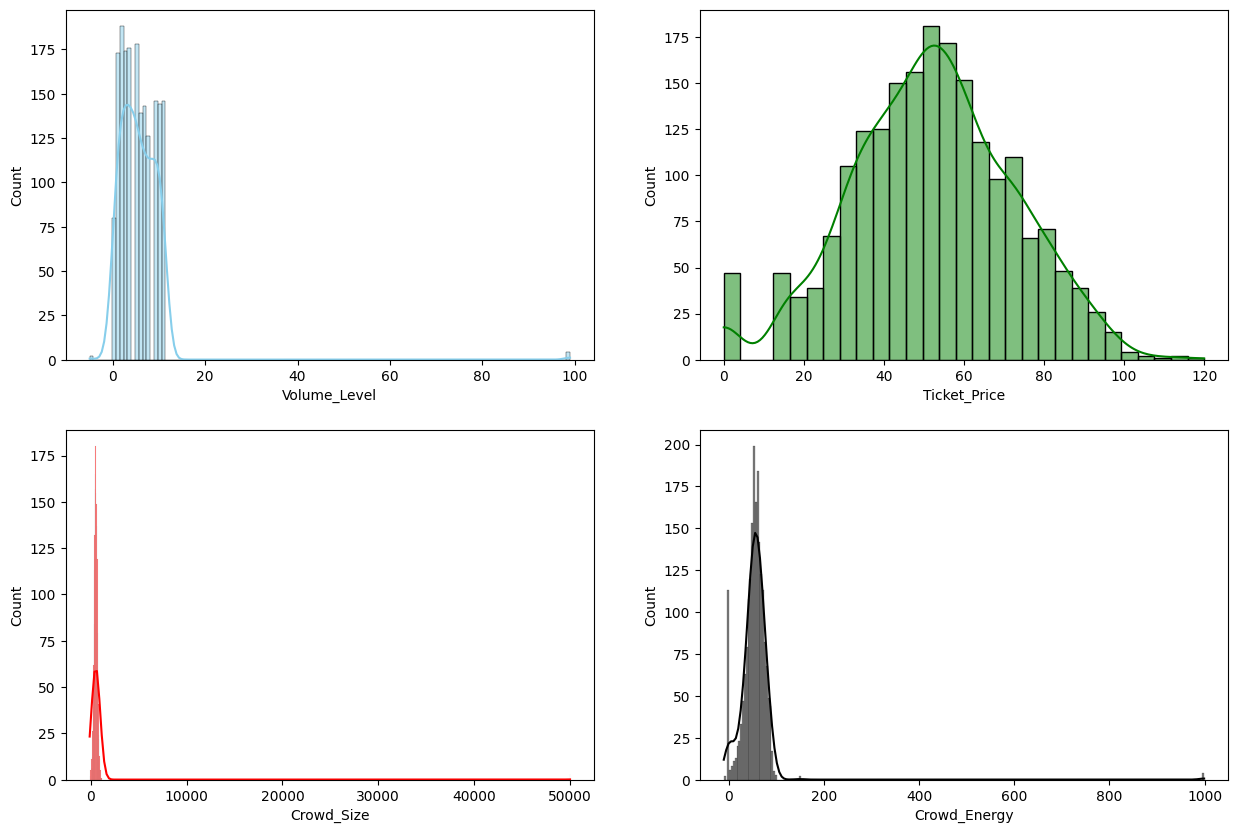

In [345]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(dfcpy['Volume_Level'].dropna(), kde=True, color='skyblue',ax=ax[0, 0])
sns.histplot(dfcpy['Crowd_Size'].dropna(), kde=True, color='red',ax=ax[1, 0])
sns.histplot(dfcpy['Ticket_Price'].dropna(), kde=True, color='green',ax=ax[0, 1])
sns.histplot(dfcpy['Crowd_Energy'].dropna(), kde=True, color='black',ax=ax[1, 1])

<Axes: xlabel='count', ylabel='Band_Outfit'>

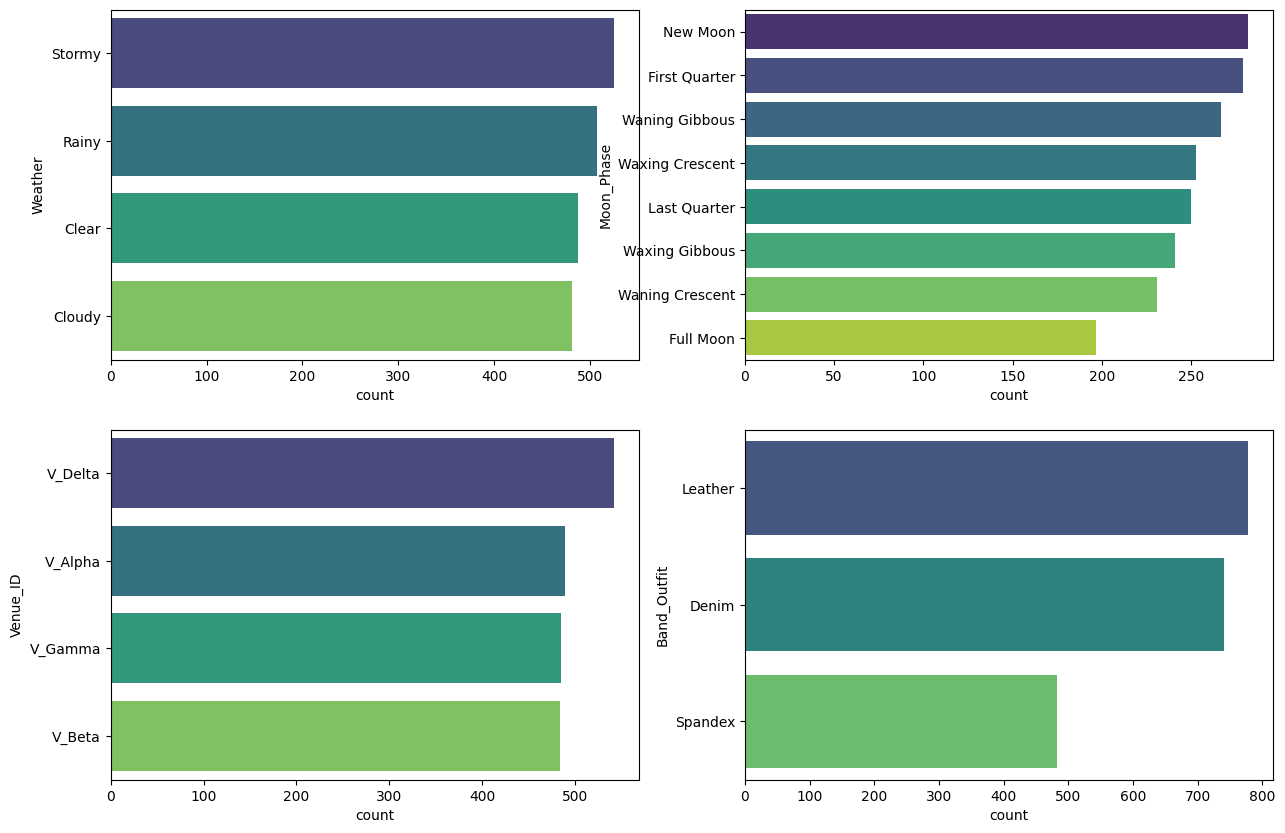

In [346]:
import warnings
warnings.filterwarnings("ignore")
fig1, ax1 = plt.subplots(2, 2, figsize=(15, 10))
sns.countplot(y='Weather', data=dfcpy, palette='viridis', order=dfcpy['Weather'].value_counts().index, ax=ax1[0][0])
sns.countplot(y='Moon_Phase', data=dfcpy, palette='viridis', order=dfcpy['Moon_Phase'].value_counts().index, ax=ax1[0][1])
sns.countplot(y='Venue_ID', data=dfcpy, palette='viridis', order=dfcpy['Venue_ID'].value_counts().index, ax=ax1[1][0])
sns.countplot(y='Band_Outfit', data=dfcpy, palette='viridis', order=dfcpy['Band_Outfit'].value_counts().index, ax=ax1[1][1])

<Axes: ylabel='Volume_Level'>

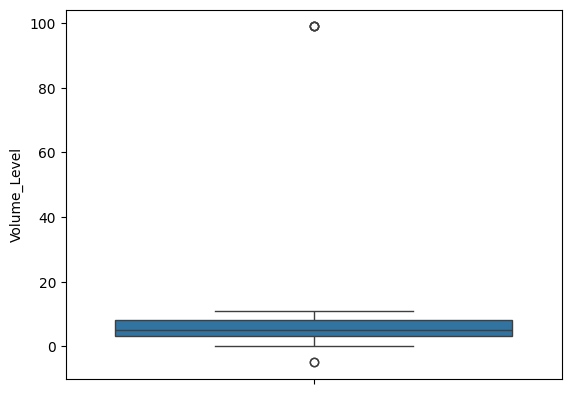

In [347]:
sns.boxplot(y=dfcpy['Volume_Level'])

<Axes: ylabel='Crowd_Size'>

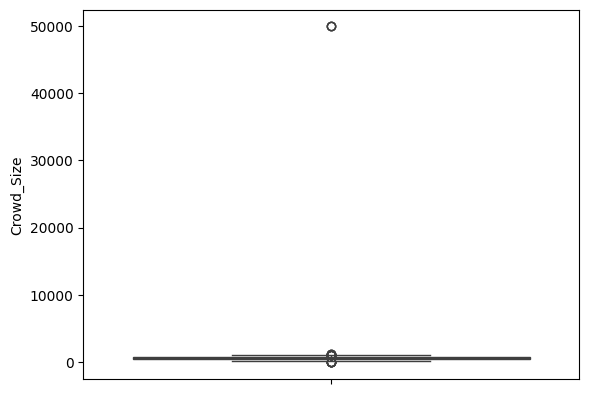

In [348]:
sns.boxplot(y=dfcpy['Crowd_Size'])

<Axes: ylabel='Crowd_Energy'>

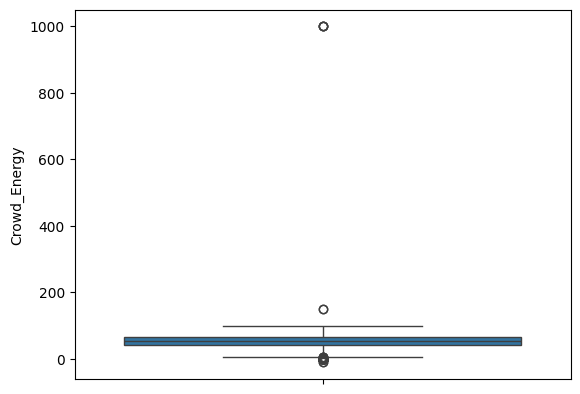

In [349]:
sns.boxplot(y=dfcpy['Crowd_Energy'])

# Observations
- `Volume_Level`, `Crowd_Size`, `Crowd_Energy` is highly skewed (outliers exists mp)
- boxplot confirms it

(But only removing impossible values for now)

In [350]:
dfcpy.loc[((dfcpy['Volume_Level']>15 )| (dfcpy['Volume_Level']<0)),'Volume_Level']=np.nan
dfcpy.loc[((dfcpy['Crowd_Size']<0) | (dfcpy['Crowd_Size']==50000)),'Crowd_Size']=np.nan
dfcpy.loc[((dfcpy['Crowd_Energy']<0 )|( dfcpy['Crowd_Energy']>100)),'Crowd_Energy']=np.nan


# Checking the Scribbles

═══════════════════════════════════════════════════════════════════════════════
PAGE 1 - TORN, COFFEE-STAINED, FOUND UNDER THE TOUR BUS SEAT
═══════════════════════════════════════════════════════════════════════════════

'Tuesday shows are CURSED. I'm absolutely certain of this. Every Tuesday 
something goes wrong. The amps exploded in Munich (Tuesday). The drummer 
got food poisoning in Prague (also Tuesday). My voice cracked in Barcelona 
(you guessed it). I've started refusing Tuesday bookings. Track this in 
the data - I bet Tuesdays have the lowest energy scores across ALL venues.'

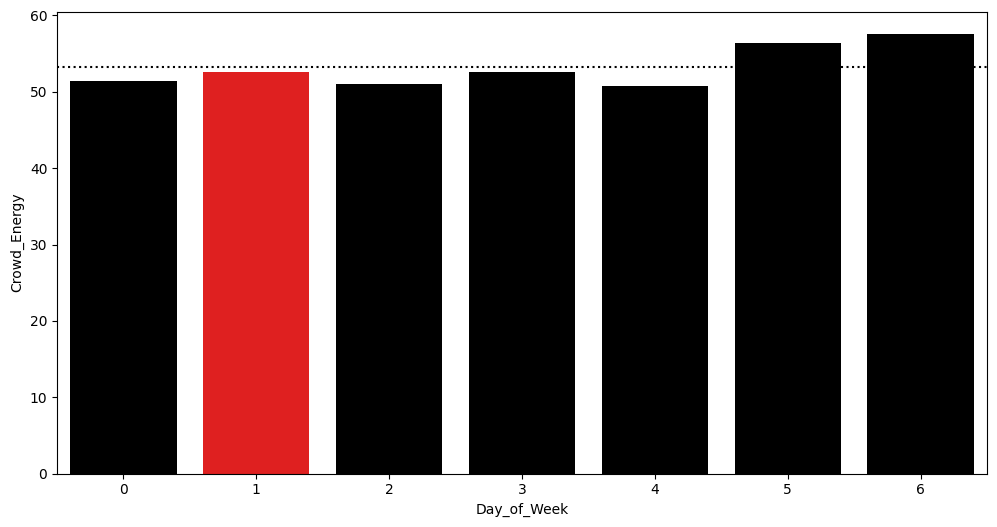

In [351]:
plt.figure(figsize=(12, 6))
colors = ['black' if day != 1 else 'red' for day in dfcpy.groupby('Day_of_Week')['Crowd_Energy'].mean().reset_index()['Day_of_Week']]
sns.barplot(data=dfcpy.groupby('Day_of_Week')['Crowd_Energy'].mean().reset_index(), x='Day_of_Week', y='Crowd_Energy', palette=colors)
avg_energy = dfcpy['Crowd_Energy'].mean()
plt.axhline(avg_energy, color='black', linestyle='dotted', label=f'averege')
plt.show()

Conclusion: This is false, it is below average but not lowest

'The monks at one of the venues... or was it the goths? Someone has a noise 
limit. Brother Thomas - the old one with the massive beard - he WINCES at 
a certain volume. Once he winces, it's over. The energy just dies. But 
here's what's weird: I've ALSO seen him tolerate absolute chaos when the 
place was packed to the rafters. Maybe he just gives up enforcing when 
there's too many people? Or maybe he's deaf in one ear and it depends 
which way he's facing? Or maybe I'm thinking of a completely different 
venue. The tours blur together, man.'


<Axes: xlabel='Venue_ID', ylabel='Volume_Level'>

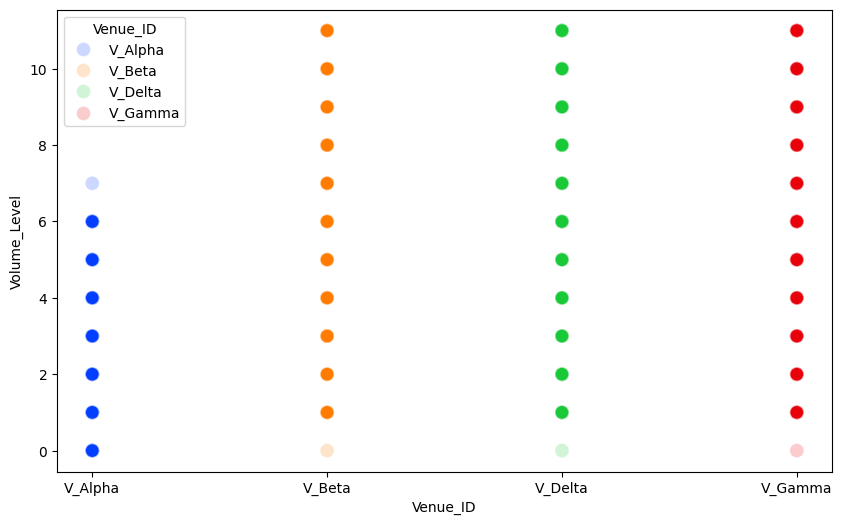

In [352]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dfcpy, x='Venue_ID', y='Volume_Level', hue='Venue_ID',s=100,alpha=0.2,palette='bright')

So, she is talking about V_Alpha here, clearly it has a noise limit of 7. Now plotting crowd energy vs vol level to check if he really winces and make the show dead. To check the whole claim i need to make two groups of crowd.

In [353]:
m_crowd = dfcpy['Crowd_Size'].median()
dfcpy['Crowd_Group'] = dfcpy['Crowd_Size'].apply(lambda x: 'H' if x > m_crowd else 'L')

<Axes: xlabel='Volume_Level', ylabel='Crowd_Energy'>

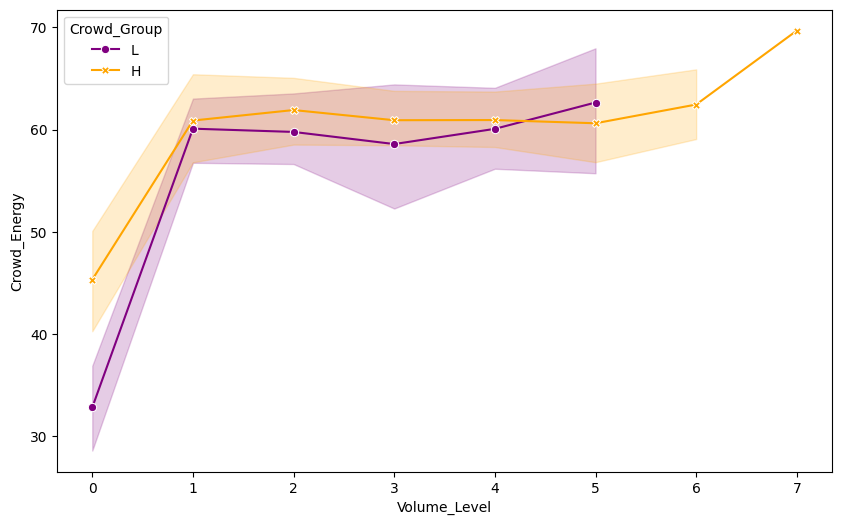

In [354]:
plt.figure(figsize=(10, 6))
sns.lineplot( data=dfcpy[dfcpy['Venue_ID']=='V_Alpha'], x='Volume_Level', y='Crowd_Energy', hue='Crowd_Group', style='Crowd_Group', markers=True,dashes=False, palette=['purple', 'orange'])

Conclusion:- He most probably winces at volume 5, and also yeah, for higher crowd he goes upto 7 and doesn't wince.

'Speaking of the goths - they ONLY come alive at night. Or wait, is that 
obvious? Every venue is better at night, right? Actually no, I remember 
a killer afternoon show somewhere. Was it the mosh pit? The monastery? 
I genuinely don't remember.
'

<Axes: xlabel='Show_Hour', ylabel='Crowd_Energy'>

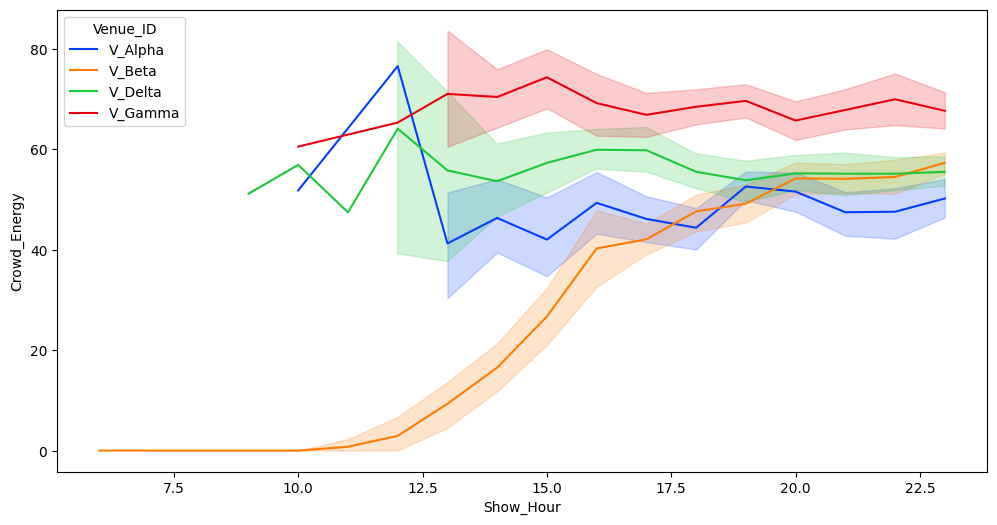

In [355]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=dfcpy, x='Show_Hour', y='Crowd_Energy', hue='Venue_ID', palette='bright')

Conclusion:- 'V_Beta' 'the goths' do come at night and it's true, as she has clearly better shows in afternoon in other venues
also the killer show was at V_Alpha what she was talking about, the monastery

═══════════════════════════════════════════════════════════════════════════════
PAGE 2 - WRITTEN IN PURPLE MARKER ON A HOTEL NAPKIN
═══════════════════════════════════════════════════════════════════════════════

'FULL MOON = MAGIC 🌕

I am CONVINCED our best shows happen during full moons. The energy is 
just... different. Electric. The crowd moves like they're possessed. 
The drummer thinks I'm insane and says it's confirmation bias. But what 
does he know? He also thinks his lucky socks affect our performance.'

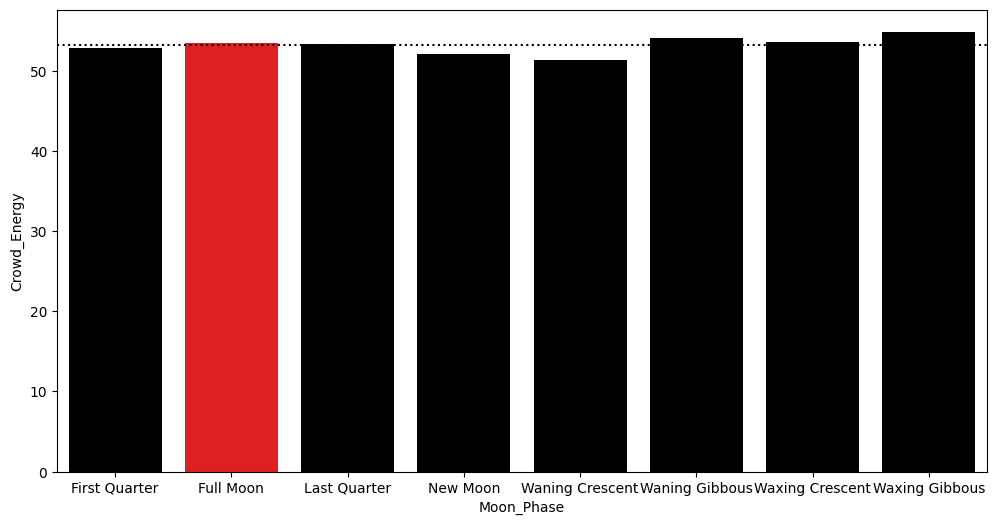

In [356]:
plt.figure(figsize=(12, 6))
colors = ['black' if day != 'Full Moon' else 'red' for day in dfcpy.groupby('Moon_Phase')['Crowd_Energy'].mean().reset_index()['Moon_Phase']]
sns.barplot(data=dfcpy.groupby('Moon_Phase')['Crowd_Energy'].mean().reset_index(), x='Moon_Phase', y='Crowd_Energy', palette=colors)
avg_energy = dfcpy['Crowd_Energy'].mean()
plt.axhline(avg_energy, color='black', linestyle='dotted', label=f'averege')
plt.show()

Conclusion:- There is no significant difference between the moon phases

'
Actually, speaking of socks - does outfit color matter? I wore red socks 
in Berlin and they went ABSOLUTELY CRAZY. Coincidence? In Amsterdam I 
wore the leather jacket and it was mid. But in Rotterdam the leather 
jacket killed. So maybe it's not about what we wear? Or maybe it is but 
it interacts with venue? The spandex always FEELS right but the data 
might say otherwise.'

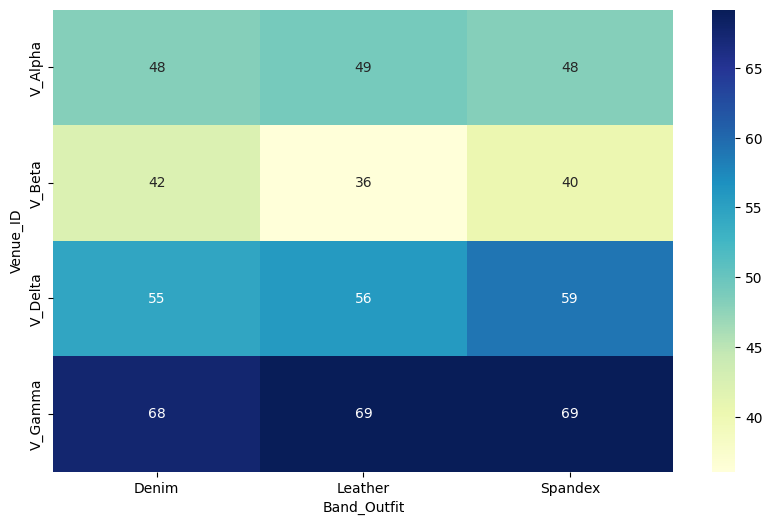

In [357]:
plt.figure(figsize=(10, 6))
sns.heatmap(dfcpy.pivot_table(index='Venue_ID', columns='Band_Outfit', values='Crowd_Energy', aggfunc='mean'), annot=True, cmap='YlGnBu')
plt.show()

Conclusion:- No clear evidence of spandex becoming best however it's true wearing leather significantly reducced energy in V_Beta compared to Denim and Spandex

'Also, I've been tracking the weather. Rain definitely sucks. But does it 
actually affect energy or does it just affect MY mood and I play worse? 
The outdoor venues (I think V_Delta is partly outdoor?) obviously suffer 
in storms. Or do they? Mosh pits in the rain are kind of legendary. 
Ugh, I don't know. Verify this.'

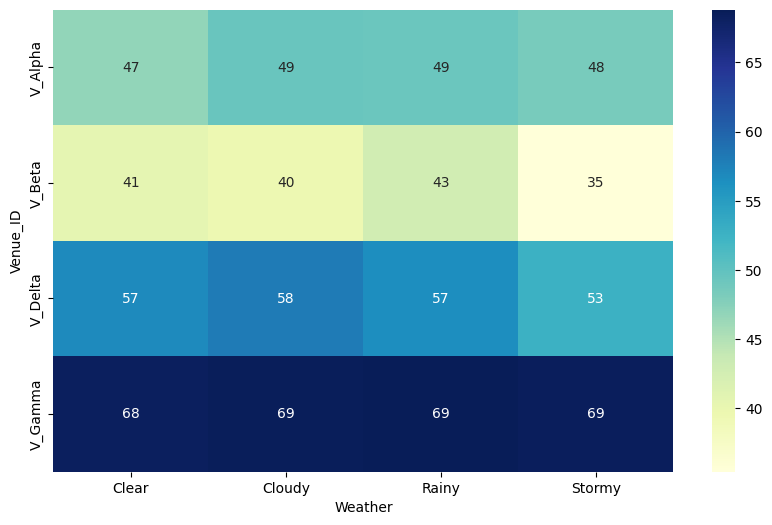

In [358]:
plt.figure(figsize=(10, 6))
sns.heatmap(dfcpy.pivot_table(index='Venue_ID', columns='Weather', values='Crowd_Energy', aggfunc='mean'), annot=True, cmap='YlGnBu')
plt.show()

Conclusion:- She is wrong, not V_Delta but V_Beta is worst in storm in V_Delta in storm it's average is less so it maybe partly outdoor and in other places it doesn't matter

═══════════════════════════════════════════════════════════════════════════════
PAGE 3 - BARELY LEGIBLE, POSSIBLY WRITTEN WHILE INTOXICATED
═══════════════════════════════════════════════════════════════════════════════

'PRICING STRATEGY NOTES (I think this was for the snobs? Or the mosh pit?)

$45 → they laughed at us. Actually booed. Threw a shoe.
$55 → mixed reactions, some dancing, some sneering
$62 → this felt like a sweet spot? Or was this a different venue?
$80 → definitely worked somewhere. Standing ovation. Or was that the 
      night we had the pyrotechnics malfunction and everyone thought
      it was part of the show?

The problem is I can't remember WHICH venue had the pricing sensitivity.
I want to say it was V_Gamma because they're snobs. But the mosh pit 
kids are broke, so maybe THEY'RE the price sensitive ones? Or maybe it's 
the monastery - monks probably care about value for money?

Also the accountant is USELESS. Half the entries are in pounds, some are 
in euros, some have dollar signs, and she logs comped tickets as "Free" 
which throws off all the averages. I once saw an entry for $500 which 
is definitely wrong - our max ticket price was like $100. And there's 
negative prices in there somehow? Fire her.

EXCHANGE RATES (I looked these up once):
£1 = $1.27 (approximately)
€1 = $1.09 (approximately)

Actually those might be outdated. Check a converter.'

I made the price column fixed already but I missed one thing I took free tickets as 0, which is wrong clearly

In [359]:
dfcpy.to_csv('Pre_Outlier.csv', index=False)

Saved because I used different outlier removing strategy later

In [360]:
dfcpy.loc[(dfcpy['Ticket_Price']==0)|(dfcpy['Ticket_Price']>100),'Ticket_Price']=np.nan

<Axes: xlabel='Ticket_Price', ylabel='Crowd_Energy'>

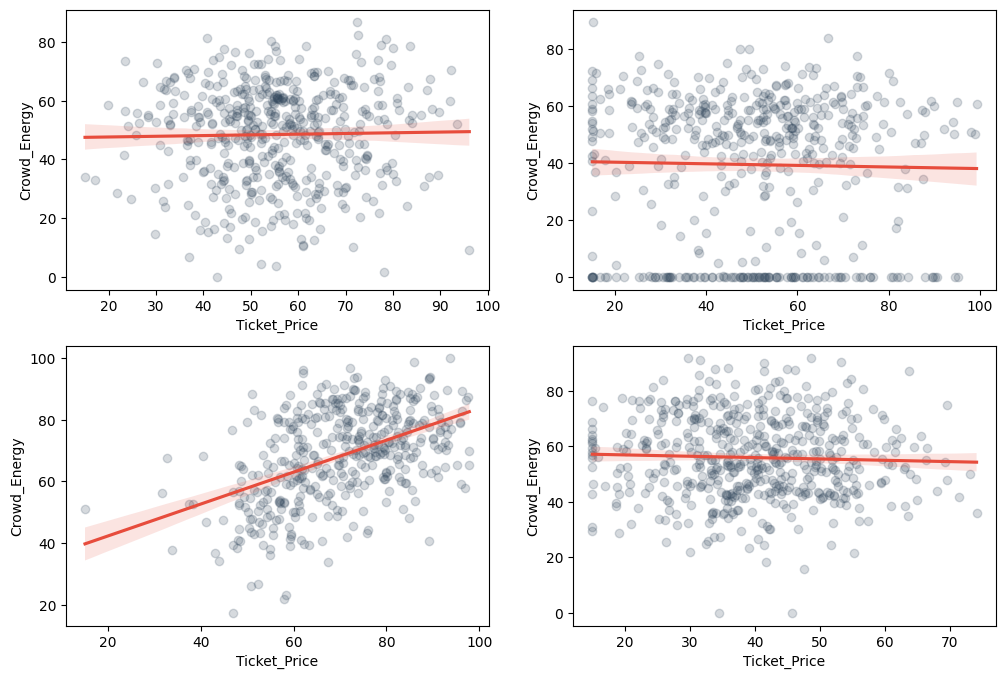

In [361]:
fig, ax= plt.subplots(2,2,figsize=(12, 8))
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Alpha'], x='Ticket_Price', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[0][0])
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Beta'], x='Ticket_Price', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[0][1])
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Gamma'], x='Ticket_Price', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[1][0])
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Delta'], x='Ticket_Price', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[1][1])

Conclusion:- Clearly In regplot it catches the trend, V_Gamma is only where Ticket_Price matters
- [Seaborn regplot documentation](https://seaborn.pydata.org/generated/seaborn.regplot.html)
This plot was better than any other plot cause it alos catches non linear trends

═══════════════════════════════════════════════════════════════════════════════
PAGE 4 - WRITTEN ON THE BACK OF A SETLIST
═══════════════════════════════════════════════════════════════════════════════

'- Crowd size matters. Obviously? Or not?'

<Axes: xlabel='Crowd_Size', ylabel='Crowd_Energy'>

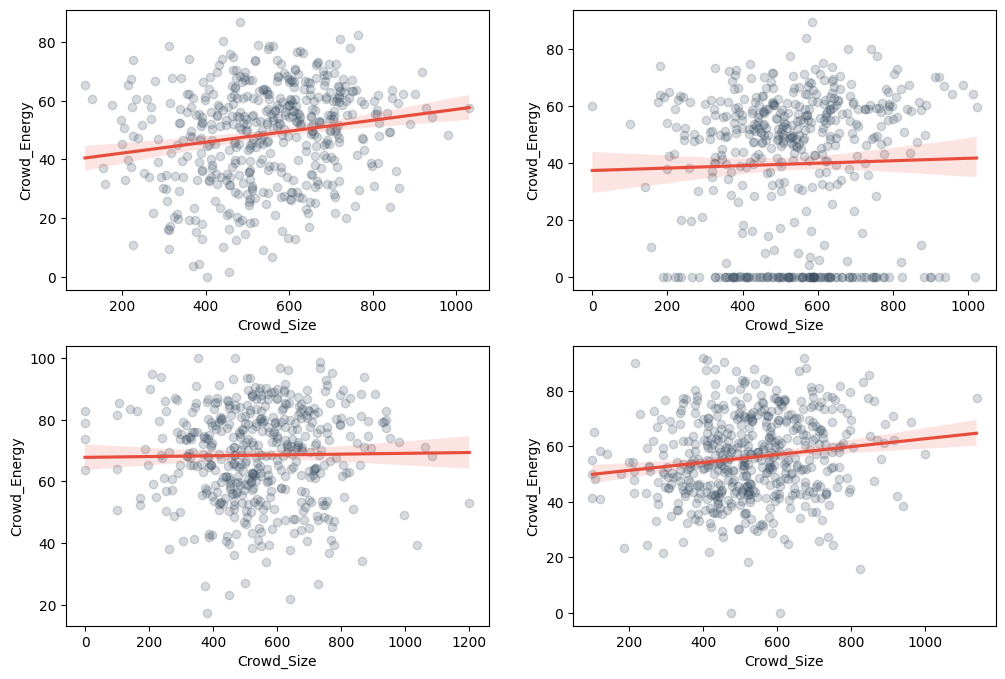

In [362]:
fig, ax= plt.subplots(2,2,figsize=(12, 8))
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Alpha'], x='Crowd_Size', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[0][0])
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Beta'], x='Crowd_Size', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[0][1])
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Gamma'], x='Crowd_Size', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[1][0])
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Delta'], x='Crowd_Size', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[1][1])

Conclusion:- while in V_Gamma, V_Beta it matters less but in V_Alpha and V_Delta it has a slightly proportional trend

'Wait, does the opener actually matter? The snobs might care about the 
"full experience." But the mosh pit kids just want to rage - they 
probably don't even notice the opener. Or maybe they do? Our data guy 
tracks opener ratings (1-5 stars) so you can check this.'

<Axes: xlabel='Opener_Rating', ylabel='Crowd_Energy'>

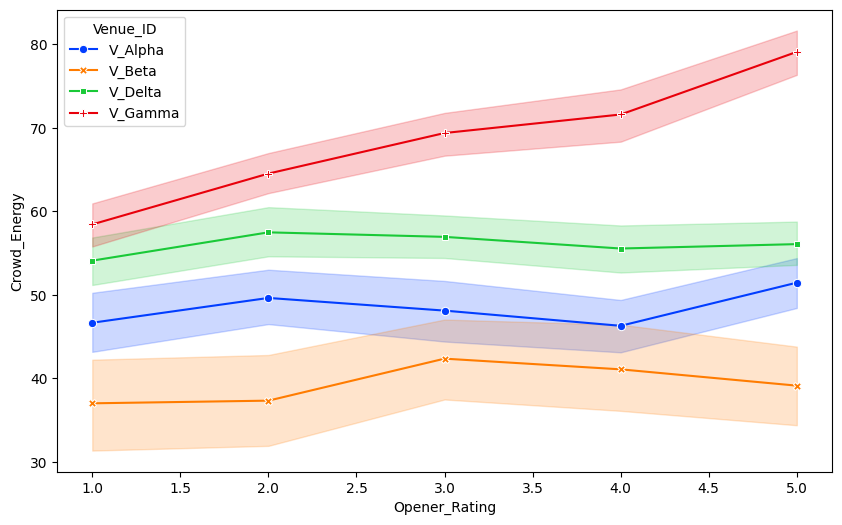

In [363]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=dfcpy, x='Opener_Rating', y='Crowd_Energy', hue='Venue_ID',style='Venue_ID', markers=True, dashes=False, palette='bright')

Conclusion:- Opener seems to have a linear relationship with opener_rating in V_Gamma

'- Volume matters. Somewhere. In some direction.'

<Axes: xlabel='Volume_Level', ylabel='Crowd_Energy'>

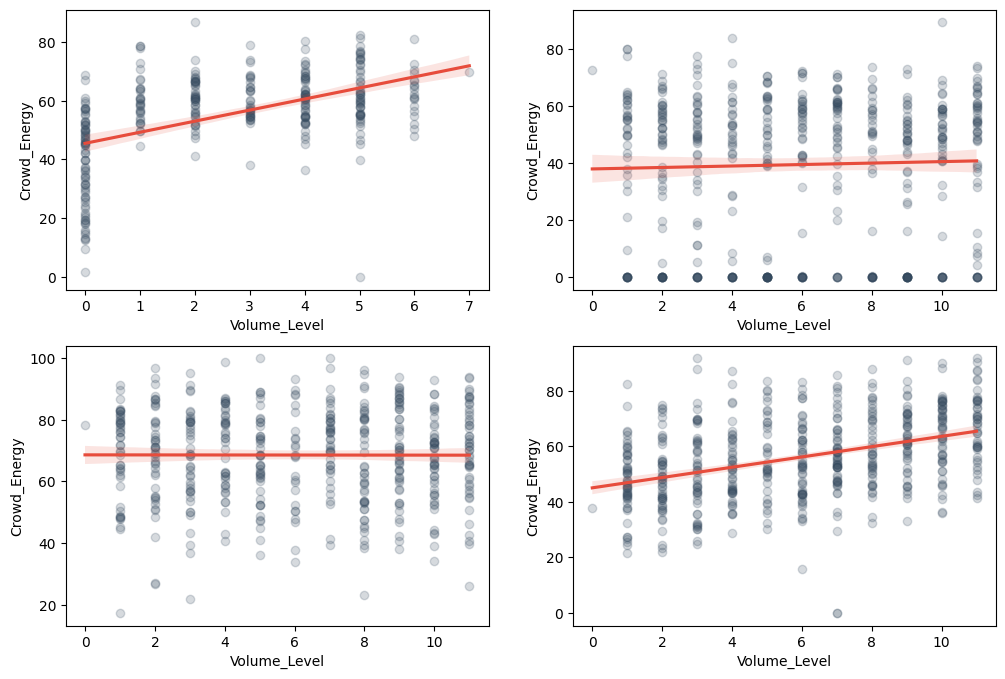

In [364]:
fig, ax= plt.subplots(2,2,figsize=(12, 8))
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Alpha'], x='Volume_Level', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[0][0])
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Beta'], x='Volume_Level', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[0][1])
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Gamma'], x='Volume_Level', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[1][0])
sns.regplot(data=dfcpy[dfcpy['Venue_ID']=='V_Delta'], x='Volume_Level', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[1][1])

Conclusion: V_Alpha and V_Delta is somewhat have a slight trend

═══════════════════════════════════════════════════════════════════════════════
PAGE 5 - WRITTEN ON AN AIRPLANE SICK BAG
═══════════════════════════════════════════════════════════════════════════════

'...is what I used to think. But looking back at the tour logs, there 
IS a pattern. The packed shows were INSANE. The empty shows were dead. 
But isn't that true everywhere? Maybe V_Delta is special because the 
effect is stronger there. The mosh pit FEEDS on itself - more people 
means more energy which means more people go crazy which means more 
energy. It's exponential. Or linear. Or logarithmic. I don't know math.'

I have plotted crowd enrgy vs cowd_size above.
Conclusion: I don't think it's much of a factor as there is a proportional trend but slope is v less

'IMPORTANT: Some of our data is absolute GARBAGE. I've seen:
- Ticket prices of $0 and $500 in the same column
- Energy scores of 999 (our scale goes to 100)
- Crowd counts of 50,000 (the biggest venue holds 1,000)
- Negative values for things that can't be negative

The data entry guy was clearly either drunk or running a crypto scam 
on the side. Clean this up before you do ANYTHING.'

In [365]:
dfcpy.loc[(dfcpy['Volume_Level']<0)|(dfcpy['Volume_Level']>11),'Volume_Level']=np.nan
dfcpy.loc[(dfcpy['Crowd_Size']<0)|(dfcpy['Crowd_Size']>1000),'Crowd_Size']=np.nan
dfcpy.loc[(dfcpy['Crowd_Energy']<0)|(dfcpy['Crowd_Energy']>100),'Crowd_Energy']=np.nan

In [366]:
dfcpy.describe()

,Show_DateTime,Day_of_Week,Volume_Level,Ticket_Price,Crowd_Size,Opener_Rating,Merch_Sales_Post_Show,Crowd_Energy,Show_Date_Month,Show_Hour,Show_Date_day
count,2000,2000.000000,1813.000000,1944.000000,1946.000000,2000.00000,2000.000000,1992.000000,1957.000000,1907.000000,1957.000000
mean,2024-06-07 16:39:30.600000,3.006000,5.442912,53.076744,533.315519,3.01700,797.040500,53.200838,5.839039,19.044048,15.493102
min,2024-01-01 10:00:00,0.000000,0.000000,15.000000,0.000000,1.00000,0.000000,0.000000,1.000000,6.000000,1.000000
25%,2024-04-16 07:15:00,1.000000,3.000000,39.692500,425.000000,2.00000,626.750000,43.150000,4.000000,17.000000,8.000000
50%,2024-06-08 21:00:00,3.000000,5.000000,52.540000,529.500000,3.00000,825.000000,55.470000,6.000000,19.000000,15.000000
75%,2024-07-30 18:30:00,5.000000,8.000000,65.680000,646.000000,4.00000,1019.000000,67.307500,7.000000,22.000000,23.000000
max,2024-12-09 16:00:00,6.000000,11.000000,99.320000,999.000000,5.00000,1529.000000,100.000000,12.000000,23.000000,31.000000
std,NaN,2.024849,3.323385,18.560766,164.819490,1.40844,323.222699,21.153674,1.951914,3.347353,8.796064


<Axes: xlabel='Venue_ID', ylabel='Crowd_Energy'>

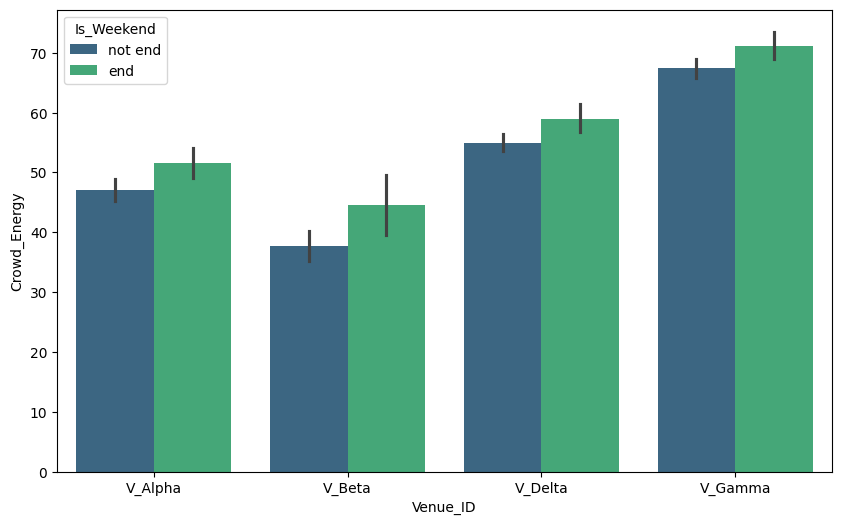

In [367]:
dfcpy['Is_Weekend'] = dfcpy['Day_of_Week'].apply(lambda x: 'end' if x >= 5 else 'not end')
plt.figure(figsize=(10, 6))
sns.barplot(data=dfcpy, x='Venue_ID', y='Crowd_Energy', hue='Is_Weekend', palette='viridis')

Conclusion:- Clearly Weekend shows have better average energy than other shows at all place

# Making Pipeline

In [368]:
num=['Day_of_Week','Volume_Level','Ticket_Price','Crowd_Size','Opener_Rating','Show_Date_Month','Show_Hour','Show_Date_day']
cat=['Venue_ID','Moon_Phase','Weather','Band_Outfit']

In [369]:
NumTransformer = Pipeline(steps=[
    ('tnf1',KNNImputer()),
    ('tnf2', StandardScaler())                  
])
CatTransformer = Pipeline(steps=[
    ('tnf1', SimpleImputer(strategy='most_frequent')),
    ('tnf2', OneHotEncoder(handle_unknown='ignore'))    
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', NumTransformer, num), 
        ('cat', CatTransformer, cat)
    ])

In [63]:
XGB=XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42)
RandFor=RandomForestRegressor(
        n_estimators=100,      
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1)
HistGB=HistGradientBoostingRegressor(
        learning_rate=0.1,
        max_iter=100,
        max_depth=5,
        random_state=42)
ExtraTrees=ExtraTreesRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1)
CatBoost=CatBoostRegressor(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        random_state=42)
LGBM=LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=-1,        
        num_leaves=31,       
        random_state=42,
        n_jobs=-1)


In [98]:
my_pipeline=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGB)]
)

In [117]:
df_unlabeled = dfcpy[dfcpy['Crowd_Energy'].isna()]
df_labeled = dfcpy[dfcpy['Crowd_Energy'].notna()]
X = df_labeled.drop(columns=['Crowd_Energy'], axis=1)
Y = df_labeled['Crowd_Energy']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [100]:
my_pipeline.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [101]:
Y_pred=my_pipeline.predict(X_test)
my_pipeline.score(X_test, Y_test)

0.5895661125934379

In [102]:
root_mean_squared_error(Y_pred, Y_test)

13.113088692274198

- XGB - r2 score of 0.614, rmse- 12.709 (KNN performed significantly low)
- RandFor- r2 score of 0.613, rmse- 12.729
- HistGB- r2 score of 0.607, rmse- 12.832
- ExtraTrees- r2 score of 0.6249 rmse- 12.535
- CatBoost- r2 score of 0.6244 rmse- 12.543
- LGBM- r2 score of 0.585 rmse- 13.179

In [69]:
parameters_X= [
    {   'model': [XGB],
        'model__n_estimators': [100, 200, 300, 500, 700, 1000],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [2, 4, 6, 8, 10, 12],
        'model__subsample': [0.6, 0.8, 1.0]}
]
grid_search = GridSearchCV(
    estimator=my_pipeline,
    param_grid=parameters_X,
    cv=5,
    scoring='r2',
    n_jobs=-1
)


In [ ]:
grid_search.fit(X_train, Y_train)

In [ ]:
Y_pred2=grid_search.predict(X_test)

In [ ]:
root_mean_squared_error(Y_pred2,Y_test)

12.32976350036743

In [ ]:
r2_score(Y_test,Y_pred2)

0.6371369835141422

XGB- grid_search score: 0.6371 rmse 12.329

In [ ]:
best_parameters_XGB=grid_search.best_params_

In [ ]:
parameters_R= [
    {   'model': [RandFor],
        'model__n_estimators': [50, 100, 200, 300, 400, 500, 600],
        'model__max_depth': [None, 5, 10, 15, 20, 25],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]}]
grid_search = GridSearchCV(
    estimator=my_pipeline,
    param_grid=parameters_R,
    cv=5,
    scoring='r2',
    n_jobs=-1
)


In [ ]:
grid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 378 candidates, totalling 1890 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'model': [RandomForestR...ndom_state=42)], 'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}]"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [ ]:
Y_pred2=grid_search.predict(X_test)

In [ ]:
root_mean_squared_error(Y_pred2,Y_test)

12.394097455772254

In [ ]:
r2_score(Y_test,Y_pred2)

0.6333404279532924

XGB- grid_search score: 0.63334 rmse 12.39409

In [ ]:
best_parameters_RandFor=grid_search.best_params_

In [ ]:
parameters_H = [
    {   'model': [HistGB],
        'model__max_iter': [100, 200, 300, 500, 700, 1000],
        'model__max_depth': [3, 5, 8, 10, 15, 20],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__l2_regularization': [0, 0.1, 1.0]
    }
]
grid_search = GridSearchCV(
    estimator=my_pipeline,
    param_grid=parameters_H,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [ ]:
grid_search.fit(X_train, Y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'model': [HistGradientB...ndom_state=42)], 'model__l2_regularization': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], ...}]"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [ ]:
Y_pred2=grid_search.predict(X_test)

In [ ]:
root_mean_squared_error(Y_pred2,Y_test)

12.752755273161522

In [ ]:
r2_score(Y_test,Y_pred2)

0.6118127517101131

HistGB- grid_search score: 0.6118 rmse 12.75

In [76]:
parameters_ET = [
    {
        'model': [ExtraTrees],
        'model__n_estimators': [50, 100, 200, 300, 400, 500],
        'model__max_depth': [None, 5, 10, 15, 20, 25],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }
]
grid_search = GridSearchCV(
    estimator=my_pipeline,
    param_grid=parameters_ET,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [77]:
grid_search.fit(X_train, Y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'model': [ExtraTreesReg...ndom_state=42)], 'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}]"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [78]:
Y_pred2=grid_search.predict(X_test)

In [79]:
root_mean_squared_error(Y_pred2,Y_test)

12.278782066187462

In [80]:
r2_score(Y_test,Y_pred2)

0.6401315310315233

ExtraTrees- grid_search score: 0.640 rmse 12.278

In [86]:
parameters_CB = [
    {
        'model': [CatBoost],
        'model__iterations': [100, 200, 300, 500, 700, 1000],
        'model__depth': [3, 4, 5, 6, 8, 10],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__l2_leaf_reg': [1, 3, 5],
        'model__verbose': [0]
    }
]
grid_search = GridSearchCV(
    estimator=my_pipeline,
    param_grid=parameters_CB,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [88]:
grid_search.fit(X_train, Y_train)

,estimator,Pipeline(step...9C45425840>)])
,param_grid,"[{'model': [<catboost.cor...0019C45425840>], 'model__depth': [3, 4, ...], 'model__iterations': [100, 200, ...], 'model__l2_leaf_reg': [1, 3, ...], ...}]"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [89]:
Y_pred2=grid_search.predict(X_test)

In [90]:
root_mean_squared_error(Y_pred2,Y_test)

12.69208870363068

In [91]:
r2_score(Y_test,Y_pred2)

0.6154972846532533

# Here XGBM performed best but I need to do more feature engineering to decrease RMSE

In [103]:
dfcpy

,Gig_ID,Venue_ID,Show_DateTime,Day_of_Week,Volume_Level,Ticket_Price,Crowd_Size,Opener_Rating,Weather,Moon_Phase,Band_Outfit,Merch_Sales_Post_Show,Crowd_Energy,Show_Date_Month,Show_Hour,Show_Date_day,Crowd_Group,Is_Weekend
0,Gig_0000,V_Alpha,2024-03-07 21:00:00,3,5.0,52.93,464.0,2,Rainy,Waning Crescent,Leather,916,64.96,3.0,21.0,7.0,L,not end
1,Gig_0001,V_Beta,2024-09-05 22:00:00,3,2.0,66.33,388.0,5,Clear,New Moon,Leather,1003,66.42,9.0,22.0,5.0,L,not end
2,Gig_0002,V_Delta,2024-03-09 15:00:00,5,1.0,51.37,679.0,1,Rainy,Waning Crescent,Denim,720,42.58,3.0,15.0,9.0,H,end
3,Gig_0003,V_Beta,2024-08-07 08:00:00,0,10.0,64.77,454.0,1,Rainy,New Moon,Leather,0,0.00,8.0,8.0,7.0,L,not end
4,Gig_0004,V_Delta,2024-04-26 17:00:00,4,8.0,47.34,654.0,5,Cloudy,Full Moon,Spandex,950,67.55,4.0,17.0,26.0,H,not end
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Gig_1995,V_Alpha,2024-06-16 20:00:00,6,NaN,57.34,699.0,5,Stormy,First Quarter,Denim,601,40.67,6.0,20.0,16.0,H,end
1996,Gig_1996,V_Beta,2024-05-23 23:00:00,3,7.0,26.94,588.0,5,Stormy,Full Moon,Spandex,897,65.60,5.0,23.0,23.0,H,not end
1997,Gig_1997,V_Beta,2024-01-01 23:00:00,4,2.0,57.54,649.0,1,Rainy,Waning Gibbous,Leather,670,60.34,NaN,23.0,NaN,H,not end
1998,Gig_1998,V_Beta,2024-05-28 00:00:00,1,9.0,53.37,503.0,1,Rainy,Waning Gibbous,Leather,597,NaN,5.0,NaN,28.0,L,not end


In [106]:
numeric_df = dfcpy.select_dtypes(include=['number'])
numeric_df.corr()['Crowd_Energy'].sort_values()

Show_Date_Month         -0.014598
Show_Date_day            0.024606
Crowd_Size               0.071957
Day_of_Week              0.086091
Opener_Rating            0.090819
Volume_Level             0.131823
Ticket_Price             0.180203
Show_Hour                0.388289
Merch_Sales_Post_Show    0.946902
Crowd_Energy             1.000000
Name: Crowd_Energy, dtype: float64

Observation: Show hour has significant corelation with crowd energy 0.388 but after that corelation has dropped severly, trying new features

In [110]:
dfcpy['tick-cr']=dfcpy['Ticket_Price']*dfcpy['Crowd_Size']
dfcpy['vol-pr']=dfcpy['Volume_Level']*dfcpy['Ticket_Price']
dfcpy['dw-sh']=dfcpy['Day_of_Week']*dfcpy['Show_Hour']

Here we don't need to think about multi collinearity as i'm not gonna use linear models

In [111]:
numeric_df = dfcpy.select_dtypes(include=['number'])
numeric_df.corr()['Crowd_Energy'].sort_values()

Show_Date_Month         -0.014598
Show_Date_day            0.024606
Crowd_Size               0.071957
Day_of_Week              0.086091
Opener_Rating            0.090819
Volume_Level             0.131823
dw-sh                    0.174087
tick-cr                  0.177456
Ticket_Price             0.180203
vol-pr                   0.199154
Show_Hour                0.388289
Merch_Sales_Post_Show    0.946902
Crowd_Energy             1.000000
Name: Crowd_Energy, dtype: float64

'vol-pr' has significan correlation

In [112]:
dfcpy.describe()

,Show_DateTime,Day_of_Week,Volume_Level,Ticket_Price,Crowd_Size,Opener_Rating,Merch_Sales_Post_Show,Crowd_Energy,Show_Date_Month,Show_Hour,Show_Date_day,tick-cr,vol-pr,dw-sh
count,2000,2000.000000,1813.000000,1944.000000,1946.000000,2000.00000,2000.000000,1992.000000,1957.000000,1907.000000,1957.000000,1891.000000,1757.000000,1907.000000
mean,2024-06-07 16:39:30.600000,3.006000,5.442912,53.076744,533.315519,3.01700,797.040500,53.200838,5.839039,19.044048,15.493102,28281.033173,283.109943,57.033561
min,2024-01-01 10:00:00,0.000000,0.000000,15.000000,0.000000,1.00000,0.000000,0.000000,1.000000,6.000000,1.000000,0.000000,0.000000,0.000000
25%,2024-04-16 07:15:00,1.000000,3.000000,39.692500,425.000000,2.00000,626.750000,43.150000,4.000000,17.000000,8.000000,18651.705000,115.950000,21.000000
50%,2024-06-08 21:00:00,3.000000,5.000000,52.540000,529.500000,3.00000,825.000000,55.470000,6.000000,19.000000,15.000000,26592.440000,236.600000,57.000000
75%,2024-07-30 18:30:00,5.000000,8.000000,65.680000,646.000000,4.00000,1019.000000,67.307500,7.000000,22.000000,23.000000,36318.965000,397.810000,90.000000
max,2024-12-09 16:00:00,6.000000,11.000000,99.320000,999.000000,5.00000,1529.000000,100.000000,12.000000,23.000000,31.000000,90418.600000,1075.140000,138.000000
std,NaN,2.024849,3.323385,18.560766,164.819490,1.40844,323.222699,21.153674,1.951914,3.347353,8.796064,13602.577057,212.473010,40.359714


# Let's train model on this

In [113]:
num1=['Day_of_Week','Volume_Level','Ticket_Price','Crowd_Size','Opener_Rating','Show_Date_Month','Show_Hour','Show_Date_day','vol-pr']
cat1=['Venue_ID','Moon_Phase','Weather','Band_Outfit']

In [114]:
NumTransformer = Pipeline(steps=[
    ('tnf1',SimpleImputer(strategy='median')),
    ('tnf2', StandardScaler())                  
])
CatTransformer = Pipeline(steps=[
    ('tnf1', SimpleImputer(strategy='most_frequent')),
    ('tnf2', OneHotEncoder(handle_unknown='ignore'))    
])
preprocessor1 = ColumnTransformer(
    transformers=[
        ('num', NumTransformer, num1), 
        ('cat', CatTransformer, cat1)
    ])

In [115]:
my_pipeline1=Pipeline(steps=[
        ('preprocessor', preprocessor1),
        ('model', RandomForestRegressor(
    n_estimators=300,     
    max_depth=10,        
    min_samples_split=10,   
    min_samples_leaf=2,    
    random_state=42,
    n_jobs=-1              
))
]
)


In [118]:
my_pipeline1.fit(X_train,Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [119]:
my_pipeline1.score(X_test,Y_test)

0.6543726739369595

- It improved - Checked the imputation, simple Imputer performing a lot better than KNNImputer, mayb bcos the data is noisy

- Checking how I dealt with Outliers, I replaced them with nan values, let me check with winsorisation

In [370]:
df2cpy=pd.read_csv('Pre_Outlier.csv')

In [371]:
df2cpy

,Gig_ID,Venue_ID,Show_DateTime,Day_of_Week,Volume_Level,Ticket_Price,Crowd_Size,Opener_Rating,Weather,Moon_Phase,Band_Outfit,Merch_Sales_Post_Show,Crowd_Energy,Show_Date_Month,Show_Hour,Show_Date_day,Crowd_Group
0,Gig_0000,V_Alpha,2024-03-07 21:00:00,3,5.0,52.93,464.0,2,Rainy,Waning Crescent,Leather,916,64.96,3.0,21.0,7.0,L
1,Gig_0001,V_Beta,2024-09-05 22:00:00,3,2.0,66.33,388.0,5,Clear,New Moon,Leather,1003,66.42,9.0,22.0,5.0,L
2,Gig_0002,V_Delta,2024-03-09 15:00:00,5,1.0,51.37,679.0,1,Rainy,Waning Crescent,Denim,720,42.58,3.0,15.0,9.0,H
3,Gig_0003,V_Beta,2024-08-07 08:00:00,0,10.0,64.77,454.0,1,Rainy,New Moon,Leather,0,0.00,8.0,8.0,7.0,L
4,Gig_0004,V_Delta,2024-04-26 17:00:00,4,8.0,47.34,654.0,5,Cloudy,Full Moon,Spandex,950,67.55,4.0,17.0,26.0,H
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Gig_1995,V_Alpha,2024-06-16 20:00:00,6,NaN,57.34,699.0,5,Stormy,First Quarter,Denim,601,40.67,6.0,20.0,16.0,H
1996,Gig_1996,V_Beta,2024-05-23 23:00:00,3,7.0,26.94,588.0,5,Stormy,Full Moon,Spandex,897,65.60,5.0,23.0,23.0,H
1997,Gig_1997,V_Beta,2024-01-01 23:00:00,4,2.0,57.54,649.0,1,Rainy,Waning Gibbous,Leather,670,60.34,NaN,23.0,NaN,H
1998,Gig_1998,V_Beta,2024-05-28 00:00:00,1,9.0,53.37,503.0,1,Rainy,Waning Gibbous,Leather,597,NaN,5.0,NaN,28.0,L


In [372]:
df2cpy['vol-pr']=df2cpy['Volume_Level']*df2cpy['Ticket_Price']

In [397]:
df2cpy.loc[df2cpy['Crowd_Size']>1000,'Crowd_Size']=1000
df2cpy.loc[df2cpy['Ticket_Price']>100,'Ticket_Price']=100
df3cpy=df2cpy.copy()

In [399]:
df2cpy.loc[df2cpy['Crowd_Size']==0,'Crowd_Size']=np.nan

In [516]:
df_unlabeled1 = df2cpy[df2cpy['Crowd_Energy'].isna()]
df_labeled1 = df2cpy[(df2cpy['Crowd_Energy'].notna())]
X1 = df_labeled1.drop(columns=['Crowd_Energy'], axis=1)
Y1 = df_labeled1['Crowd_Energy']
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X1, Y1, test_size=0.2, random_state=42)

In [525]:
my_pipeline1.fit(X_train1,Y_train1)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [526]:
my_pipeline1.score(X_test1,Y_test1)

0.6640171081419924

In [527]:
Y_pred2=my_pipeline1.predict(X_test1)

In [528]:
root_mean_squared_error(Y_pred2,Y_test1)

11.864296047504364

# It improved significantly

In [ ]:
parameters_optuna = {
    'model__n_estimators': IntDistribution(100, 1000, step=100),
    'model__max_depth': IntDistribution(5, 50),
    'model__min_samples_split': IntDistribution(2, 20),
    'model__min_samples_leaf': IntDistribution(1, 10),
    'model__max_features': CategoricalDistribution(['sqrt', 'log2', 1.0]),
    'model__bootstrap': CategoricalDistribution([True, False])
}


optuna uses Bayesian Optimization...... treats the search as a learning problem,looks at the results of previous trials to predict which parameters are likely to perform better
Idea and source: [CampusX tuning using Optuna](https://youtu.be/E2b3SKMw934?si=G0hNpk-kF2Ax4RwR)

In [ ]:
opts = OptunaSearchCV(
    my_pipeline1,
    parameters_optuna,
    cv=5,
    n_trials=50,
    random_state=42,
    scoring='neg_mean_squared_error'
)

opts.fit(X_train1,Y_train1)

[I 2025-12-29 03:07:55,031] A new study created in memory with name: no-name-0265b80f-df63-4701-a3f2-285e8eeddd0a
[I 2025-12-29 03:07:56,822] Trial 0 finished with value: -199.41909986899984 and parameters: {'model__n_estimators': 500, 'model__max_depth': 43, 'model__min_samples_split': 3, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__bootstrap': False}. Best is trial 0 with value: -199.41909986899984.
[I 2025-12-29 03:07:58,658] Trial 1 finished with value: -248.80200383037536 and parameters: {'model__n_estimators': 400, 'model__max_depth': 21, 'model__min_samples_split': 20, 'model__min_samples_leaf': 6, 'model__max_features': 1.0, 'model__bootstrap': False}. Best is trial 0 with value: -199.41909986899984.
[I 2025-12-29 03:08:00,463] Trial 2 finished with value: -211.21246824982845 and parameters: {'model__n_estimators': 500, 'model__max_depth': 48, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__bootstrap'

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__bootstrap': CategoricalDi...(True, False)), 'model__max_depth': IntDistributi...low=5, step=1), 'model__max_features': CategoricalDi... 'log2', 1.0)), 'model__min_samples_leaf': IntDistributi...low=1, step=1), ...}"
,cv,5
,enable_pruning,False
,error_score,nan
,max_iter,1000
,n_jobs,1
,n_trials,50
,random_state,42
,refit,True
,return_train_score,False


In [520]:
opts.best_estimator_.score(X_test1,Y_test1)

0.6632392078465823

# It didn't Improve

# Now let explore if individual venue models perform better

In [151]:
v_alpha=dfcpy[dfcpy['Venue_ID']=='V_Alpha']
v_beta=dfcpy[dfcpy['Venue_ID']=='V_Beta']
v_gamma=dfcpy[dfcpy['Venue_ID']=='V_Gamma']
v_delta=dfcpy[dfcpy['Venue_ID']=='V_Delta']

In [159]:
v_alpha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 489 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Gig_ID                 489 non-null    object        
 1   Venue_ID               489 non-null    object        
 2   Show_DateTime          489 non-null    datetime64[ns]
 3   Day_of_Week            489 non-null    int64         
 4   Volume_Level           306 non-null    float64       
 5   Ticket_Price           489 non-null    float64       
 6   Crowd_Size             477 non-null    float64       
 7   Opener_Rating          489 non-null    int64         
 8   Weather                489 non-null    object        
 9   Moon_Phase             489 non-null    object        
 10  Band_Outfit            489 non-null    object        
 11  Merch_Sales_Post_Show  489 non-null    int64         
 12  Crowd_Energy           487 non-null    float64       
 13  Show_Date

In [196]:
v_alpha['vol-crow']=v_alpha['Volume_Level']*v_alpha['Crowd_Size']

In [197]:
numeric_alpha = v_alpha.select_dtypes(include=['number'])
numeric_alpha.corr()['Crowd_Energy'].sort_values()

Show_Date_day           -0.033411
Ticket_Price             0.020737
Show_Date_Month          0.043832
Opener_Rating            0.047321
Show_Hour                0.074725
Day_of_Week              0.144018
tick-cr                  0.144447
dw-sh                    0.148420
Crowd_Size               0.177241
vol-crow                 0.450678
vol-pr                   0.479802
Volume_Level             0.510970
Merch_Sales_Post_Show    0.903335
Crowd_Energy             1.000000
Name: Crowd_Energy, dtype: float64

- Here clearly the best feature is volume level but this looks a problem as it has too much missing values, so filling them randomly/mean-medisn might give a problem, so I'm thinking of mice. Cause in these type of data we need accuracy, and mice regress this as target, source:- [CampusX](https://youtu.be/a38ehxv3kyk?si=yIO0s193vhNGmVNJ)

In [219]:
num1alpha=['Day_of_Week','Crowd_Size','Opener_Rating','Show_Date_Month','Show_Hour','Show_Date_day','vol-pr']
num2alpha=['Volume_Level']
catalpha=['Moon_Phase','Weather','Band_Outfit']

In [220]:
Num1Transformeralpha = Pipeline(steps=[
    ('tnf1',SimpleImputer(strategy='median')),
    ('tnf2', StandardScaler())                  
])
Num2Transformeralpha =Pipeline(
    steps=[
        ('tnf1',IterativeImputer(max_iter=10, random_state=0)),
        ('tnf2', StandardScaler())  
    ]
)
CatTransformeralpha = Pipeline(steps=[
    ('tnf1', SimpleImputer(strategy='most_frequent')),
    ('tnf2', OneHotEncoder(handle_unknown='ignore'))    
])
preprocessoralpha = ColumnTransformer(
    transformers=[
        ('num', Num1Transformeralpha, num1alpha),
        ('num2',Num2Transformeralpha, num2alpha),
        ('cat', CatTransformeralpha, catalpha)
    ])

In [221]:
my_pipelinealpha=Pipeline(steps=[
        ('preprocessor', preprocessoralpha),
        ('model', RandomForestRegressor(
    n_estimators=300,     
    max_depth=10,        
    min_samples_split=10,   
    min_samples_leaf=2,    
    random_state=42,
    n_jobs=-1              
))
]
)


In [222]:
alpha_unlabeled1 = v_alpha[v_alpha['Crowd_Energy'].isna()]
alpha_labeled1 = v_alpha[v_alpha['Crowd_Energy'].notna()]
Xalpha = alpha_labeled1.drop(columns=['Crowd_Energy'], axis=1)
Yalpha = alpha_labeled1['Crowd_Energy']
X_trainalpha, X_testalpha, Y_trainalpha, Y_testalpha = train_test_split(Xalpha, Yalpha, test_size=0.2, random_state=42)

In [223]:
my_pipelinealpha.fit(X_trainalpha,Y_trainalpha)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('num2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [224]:
my_pipelinealpha.score(X_testalpha,Y_testalpha)

0.4449146443885392

- num1alpha=['Day_of_Week','Ticket_Price','Crowd_Size','Opener_Rating','Show_Date_Month','Show_Hour','Show_Date_day','vol-pr']
- num2alpha=['Volume_Level']
- catalpha=['Moon_Phase','Weather','Band_Outfit']
   - -> R2-0.437 
    - removing moon phase made it 0.425
    - removing date day made it 0.424
    - removing ticket price made a significant amount 0.4449 #Ticket price is pure noise for v_alpha
    - introducing'vol-crow' decreased r2 to 0.442
             

In [246]:
param_alpha = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}
grid_searchalpha = GridSearchCV(
    estimator=my_pipelinealpha,
    param_grid=param_alpha,
    cv=5,            
    n_jobs=-1,       
    verbose=2,       
    scoring='r2'     
)

In [247]:
grid_searchalpha.fit(X_trainalpha,Y_trainalpha)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('num2', ...), ...]"


In [248]:
grid_searchalpha.best_estimator_.score(X_testalpha,Y_testalpha)

0.44530222224226945

In [230]:
Y_predalpha=my_pipeline1.predict(X_testalpha)

In [231]:
root_mean_squared_error(Y_predalpha,Y_testalpha)

10.084906674349586

13.155 here vs the previous big model result 10.08

I could not improve RMSE by using this venue, it increased, maybe this venue data is chaotic

In [232]:
v_beta.info()

<class 'pandas.core.frame.DataFrame'>
Index: 484 entries, 1 to 1998
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Gig_ID                 484 non-null    object        
 1   Venue_ID               484 non-null    object        
 2   Show_DateTime          484 non-null    datetime64[ns]
 3   Day_of_Week            484 non-null    int64         
 4   Volume_Level           484 non-null    float64       
 5   Ticket_Price           483 non-null    float64       
 6   Crowd_Size             470 non-null    float64       
 7   Opener_Rating          484 non-null    int64         
 8   Weather                484 non-null    object        
 9   Moon_Phase             484 non-null    object        
 10  Band_Outfit            484 non-null    object        
 11  Merch_Sales_Post_Show  484 non-null    int64         
 12  Crowd_Energy           483 non-null    float64       
 13  Show_Date

In [233]:
numeric_beta = v_beta.select_dtypes(include=['number'])
numeric_beta.corr()['Crowd_Energy'].sort_values()

Ticket_Price            -0.021619
Show_Date_Month         -0.019794
tick-cr                  0.000990
vol-pr                   0.023876
Crowd_Size               0.029078
Volume_Level             0.032979
Opener_Rating            0.042028
Show_Date_day            0.054676
Day_of_Week              0.141528
dw-sh                    0.468793
Show_Hour                0.911095
Merch_Sales_Post_Show    0.966299
Crowd_Energy             1.000000
Name: Crowd_Energy, dtype: float64

Same high correlation of show hour but too much missing values

In [291]:
num1beta=['Day_of_Week','Show_Date_Month','Crowd_Size','Opener_Rating','Volume_Level','Show_Date_day','vol-pr','Ticket_Price']
num2beta=['Show_Hour']
catbeta=['Moon_Phase','Weather','Band_Outfit']

In [292]:
Num1Transformerbeta = Pipeline(steps=[
    ('tnf1',SimpleImputer(strategy='median')),
    ('tnf2', StandardScaler())                  
])
Num2Transformerbeta =Pipeline(
    steps=[
        ('tnf1',IterativeImputer(max_iter=10, random_state=0)),
        ('tnf2', StandardScaler())  
    ]
)
CatTransformerbeta = Pipeline(steps=[
    ('tnf1', SimpleImputer(strategy='most_frequent')),
    ('tnf2', OneHotEncoder(handle_unknown='ignore'))    
])
preprocessorbeta = ColumnTransformer(
    transformers=[
        ('num', Num1Transformerbeta, num1beta),
        ('num2',Num2Transformerbeta, num2beta),
        ('cat', CatTransformerbeta, catbeta)
    ])

In [294]:
my_pipelinebeta=Pipeline(steps=[
        ('preprocessor', preprocessorbeta),
        ('model', RandomForestRegressor(
    n_estimators=300,     
    max_depth=10,        
    min_samples_split=10,   
    min_samples_leaf=2,    
    random_state=42,
    n_jobs=-1              
))
]
)


In [295]:
beta_unlabeled1 = v_beta[v_beta['Crowd_Energy'].isna()]
beta_labeled1 = v_beta[v_beta['Crowd_Energy'].notna()]
Xbeta = beta_labeled1.drop(columns=['Crowd_Energy'], axis=1)
Ybeta = beta_labeled1['Crowd_Energy']
X_trainbeta, X_testbeta, Y_trainbeta, Y_testbeta = train_test_split(Xbeta, Ybeta, test_size=0.2, random_state=42)

In [296]:
my_pipelinebeta.fit(X_trainbeta,Y_trainbeta)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('num2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [297]:
my_pipelinebeta.score(X_testbeta,Y_testbeta)

0.5876325510889276

In [275]:
param_beta = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}
grid_searchbeta = GridSearchCV(
    estimator=my_pipelinebeta,
    param_grid=param_beta,
    cv=5,            
    n_jobs=-1,       
    verbose=2,       
    scoring='r2'     
)

In [276]:
grid_searchbeta.fit(X_trainbeta,Y_trainbeta)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('num2', ...), ...]"


In [277]:
grid_searchbeta.best_estimator_.score(X_testbeta,Y_testbeta)

0.6013881467033602

In [253]:
Y_predbeta=grid_searchbeta.predict(X_testbeta)

In [254]:
root_mean_squared_error(Y_predbeta,Y_testbeta)

15.317059393631405

In [256]:
Y_predbeta=my_pipeline1.predict(X_testbeta)

In [257]:
root_mean_squared_error(Y_predbeta,Y_testbeta)

13.06510853352962

removed 'show date month' worsened to 0.592, best 0.60

Again it performed poorly than the old model, this is maybe due to too much missing values in the column with high correlation

now on V_Delta

In [258]:
v_delta.info()

<class 'pandas.core.frame.DataFrame'>
Index: 542 entries, 2 to 1990
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Gig_ID                 542 non-null    object        
 1   Venue_ID               542 non-null    object        
 2   Show_DateTime          542 non-null    datetime64[ns]
 3   Day_of_Week            542 non-null    int64         
 4   Volume_Level           539 non-null    float64       
 5   Ticket_Price           542 non-null    float64       
 6   Crowd_Size             532 non-null    float64       
 7   Opener_Rating          542 non-null    int64         
 8   Weather                542 non-null    object        
 9   Moon_Phase             542 non-null    object        
 10  Band_Outfit            542 non-null    object        
 11  Merch_Sales_Post_Show  542 non-null    int64         
 12  Crowd_Energy           539 non-null    float64       
 13  Show_Date

In [259]:
numeric_delta = v_delta.select_dtypes(include=['number'])
numeric_delta.corr()['Crowd_Energy'].sort_values()

Show_Hour               -0.058943
Ticket_Price            -0.039013
Show_Date_day            0.006166
Show_Date_Month          0.011796
Opener_Rating            0.021860
dw-sh                    0.064854
Day_of_Week              0.084602
tick-cr                  0.084966
Crowd_Size               0.143624
vol-pr                   0.316789
Volume_Level             0.399985
Merch_Sales_Post_Show    0.892668
Crowd_Energy             1.000000
Name: Crowd_Energy, dtype: float64

In [304]:
num1delta=['Day_of_Week','Crowd_Size','Show_Hour','Volume_Level']
num2delta=['Volume_Level','vol-pr']
catdelta=['Weather','Band_Outfit']

In [305]:
Num1Transformerdelta = Pipeline(steps=[
    ('tnf1',SimpleImputer(strategy='median')),
    ('tnf2', StandardScaler())                  
])
Num2Transformerdelta =Pipeline(
    steps=[
        ('tnf1',IterativeImputer(max_iter=10, random_state=0)),
        ('tnf2', StandardScaler())  
    ]
)
CatTransformerdelta = Pipeline(steps=[
    ('tnf1', SimpleImputer(strategy='most_frequent')),
    ('tnf2', OneHotEncoder(handle_unknown='ignore'))    
])
preprocessordelta = ColumnTransformer(
    transformers=[
        ('num', Num1Transformerdelta, num1delta),
        ('num2',Num2Transformerdelta, num2delta),
        ('cat', CatTransformerdelta, catdelta)
    ])

In [306]:
my_pipelinedelta=Pipeline(steps=[
        ('preprocessor', preprocessordelta),
        ('model', RandomForestRegressor(
    n_estimators=300,     
    max_depth=10,        
    min_samples_split=10,   
    min_samples_leaf=2,    
    random_state=42,
    n_jobs=-1              
))
]
)


In [307]:
delta_unlabeled1 = v_delta[v_delta['Crowd_Energy'].isna()]
delta_labeled1 = v_delta[v_delta['Crowd_Energy'].notna()]
Xdelta = delta_labeled1.drop(columns=['Crowd_Energy'], axis=1)
Ydelta = delta_labeled1['Crowd_Energy']
X_traindelta, X_testdelta, Y_traindelta, Y_testdelta = train_test_split(Xdelta, Ydelta, test_size=0.2, random_state=42)

In [308]:
my_pipelinedelta.fit(X_traindelta,Y_traindelta)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('num2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [309]:
my_pipelinedelta.score(X_testdelta,Y_testdelta)

0.17576228998265264

In [287]:
param_delta = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}
grid_searchdelta = GridSearchCV(
    estimator=my_pipelinedelta,
    param_grid=param_delta,
    cv=5,            
    n_jobs=-1,       
    verbose=2,       
    scoring='r2'     
)

In [288]:
grid_searchdelta.fit(X_traindelta,Y_traindelta)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('num2', ...), ...]"


In [290]:
grid_searchdelta.best_estimator_.score(X_testdelta,Y_testdelta)

0.1781716437230476

Tried removing less relevant columns but score didn't improve at all, this data is pure noise

In [311]:
v_gamma.info()

<class 'pandas.core.frame.DataFrame'>
Index: 485 entries, 6 to 1991
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Gig_ID                 485 non-null    object        
 1   Venue_ID               485 non-null    object        
 2   Show_DateTime          485 non-null    datetime64[ns]
 3   Day_of_Week            485 non-null    int64         
 4   Volume_Level           484 non-null    float64       
 5   Ticket_Price           430 non-null    float64       
 6   Crowd_Size             467 non-null    float64       
 7   Opener_Rating          485 non-null    int64         
 8   Weather                485 non-null    object        
 9   Moon_Phase             485 non-null    object        
 10  Band_Outfit            485 non-null    object        
 11  Merch_Sales_Post_Show  485 non-null    int64         
 12  Crowd_Energy           483 non-null    float64       
 13  Show_Date

In [313]:
v_gamma.to_csv('V_GAMMA.csv',index=False)

In [312]:
numeric_gamma = v_gamma.select_dtypes(include=['number'])
numeric_gamma.corr()['Crowd_Energy'].sort_values()

Show_Hour               -0.050486
Show_Date_Month         -0.044090
Show_Date_day           -0.017330
Volume_Level            -0.001965
dw-sh                    0.020838
Day_of_Week              0.034333
Crowd_Size               0.035756
vol-pr                   0.130645
tick-cr                  0.294304
Opener_Rating            0.457507
Ticket_Price             0.473701
Merch_Sales_Post_Show    0.918914
Crowd_Energy             1.000000
Name: Crowd_Energy, dtype: float64

In [315]:
num1gamma=['Day_of_Week','Show_Date_Month','Show_Hour','Crowd_Size','Show_Date_day','vol-pr']
num2gamma=['Ticket_Price','Opener_Rating']
catgamma=['Moon_Phase','Weather','Band_Outfit']

In [316]:
Num1Transformergamma = Pipeline(steps=[
    ('tnf1',SimpleImputer(strategy='median')),
    ('tnf2', StandardScaler())                  
])
Num2Transformergamma =Pipeline(
    steps=[
        ('tnf1',IterativeImputer(max_iter=10, random_state=0)),
        ('tnf2', StandardScaler())  
    ]
)
CatTransformergamma = Pipeline(steps=[
    ('tnf1', SimpleImputer(strategy='most_frequent')),
    ('tnf2', OneHotEncoder(handle_unknown='ignore'))    
])
preprocessorgamma = ColumnTransformer(
    transformers=[
        ('num', Num1Transformergamma, num1beta),
        ('num2',Num2Transformergamma, num2beta),
        ('cat', CatTransformergamma, catbeta)
    ])

In [318]:
my_pipelinegamma=Pipeline(steps=[
        ('preprocessor', preprocessorgamma),
        ('model', RandomForestRegressor(
    n_estimators=300,     
    max_depth=10,        
    min_samples_split=10,   
    min_samples_leaf=2,    
    random_state=42,
    n_jobs=-1              
))
]
)


In [319]:
gamma_unlabeled1 = v_gamma[v_gamma['Crowd_Energy'].isna()]
gamma_labeled1 = v_gamma[v_gamma['Crowd_Energy'].notna()]
Xgamma = gamma_labeled1.drop(columns=['Crowd_Energy'], axis=1)
Ygamma = gamma_labeled1['Crowd_Energy']
X_traingamma, X_testgamma, Y_traingamma, Y_testgamma = train_test_split(Xgamma, Ygamma, test_size=0.2, random_state=42)

In [320]:
my_pipelinegamma.fit(X_traingamma,Y_traingamma)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('num2', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [321]:
my_pipelinegamma.score(X_testgamma,Y_testgamma)

0.4183314613014467

In [322]:
param_gamma = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}
grid_searchgamma = GridSearchCV(
    estimator=my_pipelinegamma,
    param_grid=param_gamma,
    cv=5,            
    n_jobs=-1,       
    verbose=2,       
    scoring='r2'     
)

In [323]:
grid_searchgamma.fit(X_traingamma,Y_traingamma)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('num2', ...), ...]"


In [324]:
grid_searchgamma.best_estimator_.score(X_testgamma,Y_testgamma)

0.41894638639837145

In [326]:
my_pipeline1.score(X_testgamma,Y_testgamma)

0.6469054992733285

# Clearly venue models couldn't outperform the big model

Listing the final model here

In [379]:
my_pipeline1

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [381]:
Y_pred1=my_pipeline1.predict(X_test1)

In [ ]:
r2_score(Y_test1,Y_pred1)

0.6639424207107452

In [383]:
root_mean_squared_error(Y_test1,Y_pred1)

11.865614663090975

In [384]:
Test_Data=pd.read_csv('tour_logs_test_input.csv')

Appl

In [385]:
def identify_format(date_str):
    s = str(date_str).strip()
    if s in ['Morning', 'Afternoon', 'Evening', 'Late Night']:
        return "Text"
    if re.match(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$', s):
        return "YYYY-MM-DD HH:MM:SS"  
    if re.match(r'^\d{2}/\d{2}/\d{4} \d{2}:\d{2} (AM|PM)$', s):
        return "Slash Format + AM/PM"   
    if re.match(r'^\d{2}-\d{2}-\d{4} \d{2}:\d{2}$', s):
        return "Dash Format"
    if re.match(r'^[A-Za-z]+ \d{2}, \d{4}$', s):
        return "Wordy Format"
    return "Unknown gibberish"
Test_Data['Date_Format_Type']=Test_Data['Show_DateTime'].apply(identify_format)
print(Test_Data['Date_Format_Type'].value_counts())


Date_Format_Type
YYYY-MM-DD HH:MM:SS     399
Dash Format              31
Slash Format + AM/PM     30
Wordy Format             25
Text                     15
Name: count, dtype: int64


In [386]:
random_dt = "2024-01-01"
time_map = {
        'Morning': '10:00:00',
        'Afternoon': '14:00:00',   
        'Evening': '19:00:00',     
        'Late Night': '23:00:00'   
    }
Test_Data.loc[Test_Data['Date_Format_Type']=='Text', 'Show_DateTime']=Test_Data.loc[Test_Data['Date_Format_Type']=='Text', 'Show_DateTime'].apply(lambda x: f"{random_dt} {time_map[x]}")
Test_Data['Show_DateTime'] = Test_Data['Show_DateTime'].apply(lambda x: pd.Timestamp(x))
Test_Data['Show_Date_Month'] = Test_Data['Show_DateTime'].dt.month
Test_Data['Show_Hour'] = Test_Data['Show_DateTime'].dt.hour
Test_Data['Show_Date_day'] = Test_Data['Show_DateTime'].dt.day
def ticket_cleaning(price):
    conversion = {'£': 1.27,'€': 1.09,'$': 1.0,'usd': 1.0}
    if pd.isna(price):
        return np.nan
    clean_str = str(price).upper().strip()
    if clean_str == 'FREE':
        return 0.0
    
    amount_match = re.search(r"(\d+\.?\d*)", clean_str)
    if not amount_match:
        return np.nan
    amount = float(amount_match.group(1))
    rate = 1.0
    
    if '£' in clean_str:
        rate = conversion['£']
    elif '€' in clean_str:
        rate = conversion['€']
    elif 'usd' in clean_str: 
        rate = conversion['usd']
        
    return round(amount * rate, 2)

Test_Data['Ticket_Price'] = Test_Data['Ticket_Price'].apply(ticket_cleaning)

In [391]:
Test_Data.describe()

,Show_DateTime,Day_of_Week,Volume_Level,Ticket_Price,Crowd_Size,Opener_Rating,Merch_Sales_Post_Show,Show_Date_Month,Show_Hour,Show_Date_day,vol-pr
count,500,500.000000,457.000000,500.000000,489.000000,500.000000,500.00000,500.00000,500.000000,500.000000,457.000000
mean,2024-06-06 16:10:40.800000,3.128000,5.201313,53.074880,535.605317,2.968000,693.41200,5.73400,17.138000,14.216000,270.337177
min,2024-01-01 10:00:00,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,1.00000,0.000000,1.000000,0.000000
25%,2024-04-14 20:45:00,1.000000,2.000000,39.927500,419.000000,2.000000,421.75000,4.00000,15.000000,7.000000,114.000000
50%,2024-06-04 02:00:00,3.000000,5.000000,52.405000,529.000000,3.000000,751.50000,6.00000,18.000000,14.000000,222.210000
75%,2024-08-03 04:00:00,5.000000,8.000000,67.135000,652.000000,4.000000,987.75000,8.00000,22.000000,21.000000,385.000000
max,2024-12-04 21:00:00,6.000000,11.000000,100.000000,1000.000000,5.000000,1489.00000,12.00000,23.000000,31.000000,1009.140000
std,NaN,2.047437,3.268496,20.410692,174.522116,1.393866,397.83363,2.20476,5.748482,8.780863,208.676300


In [390]:
Test_Data.loc[(Test_Data['Volume_Level']<0)|(Test_Data['Volume_Level']>11),'Volume_Level']=np.nan
Test_Data['vol-pr']=Test_Data['Volume_Level']*Test_Data['Ticket_Price']
Test_Data.loc[Test_Data['Crowd_Size']>1000,'Crowd_Size']=1000
Test_Data.loc[Test_Data['Ticket_Price']>100,'Ticket_Price']=100

In [587]:
my_pipeline1.fit(X1,Y1)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [588]:
predictions=my_pipeline1.predict(Test_Data)

In [589]:
submission = pd.DataFrame({
    'Gig_ID': Test_Data['Gig_ID'],
    'Crowd_Energy': predictions
})

In [590]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Gig_ID        500 non-null    object 
 1   Crowd_Energy  500 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB


In [591]:
submission.to_csv('predictions.csv',index=False)

# BONUS TASK

In [461]:
gamma=v_gamma[(v_gamma['Crowd_Size']>0)]

In [448]:
gamma

,Gig_ID,Venue_ID,Show_DateTime,Day_of_Week,Volume_Level,Ticket_Price,Crowd_Size,Opener_Rating,Weather,Moon_Phase,...,Merch_Sales_Post_Show,Crowd_Energy,Show_Date_Month,Show_Hour,Show_Date_day,Crowd_Group,Is_Weekend,tick-cr,vol-pr,dw-sh
6,Gig_0006,V_Gamma,2024-04-09 19:00:00,1,4.0,69.46,107.0,3,Clear,New Moon,...,1372,85.45,4.0,19.0,9.0,L,not end,7432.22,277.84,19.0
8,Gig_0008,V_Gamma,2024-03-12 17:00:00,1,8.0,48.05,539.0,5,Clear,New Moon,...,583,40.85,3.0,17.0,12.0,H,not end,25898.95,384.40,17.0
11,Gig_0011,V_Gamma,2024-03-21 17:00:00,3,4.0,56.79,425.0,1,Stormy,First Quarter,...,642,53.20,3.0,17.0,21.0,L,not end,24135.75,227.16,51.0
12,Gig_0012,V_Gamma,2024-06-25 20:00:00,1,11.0,79.31,441.0,3,Rainy,Waning Gibbous,...,946,61.55,6.0,20.0,25.0,L,not end,34975.71,872.41,20.0
13,Gig_0013,V_Gamma,2024-05-30 23:00:00,3,4.0,48.40,694.0,3,Clear,Waning Gibbous,...,540,40.54,5.0,23.0,30.0,H,not end,33589.60,193.60,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1966,Gig_1966,V_Gamma,2024-03-14 18:00:00,3,11.0,71.00,643.0,3,Rainy,Waxing Crescent,...,1076,71.56,3.0,18.0,14.0,H,not end,45653.00,781.00,54.0
1968,Gig_1968,V_Gamma,2024-06-28 17:00:00,4,9.0,52.56,599.0,3,Cloudy,Waning Gibbous,...,809,46.92,6.0,17.0,28.0,H,not end,31483.44,473.04,68.0
1970,Gig_1970,V_Gamma,2024-06-13 19:00:00,3,6.0,63.52,272.0,1,Clear,Waxing Crescent,...,899,57.28,6.0,19.0,13.0,L,not end,17277.44,381.12,57.0
1977,Gig_1977,V_Gamma,2024-04-04 17:00:00,3,9.0,NaN,613.0,3,Clear,Last Quarter,...,811,63.83,4.0,17.0,4.0,H,not end,NaN,NaN,51.0


<Axes: xlabel='Crowd_Size', ylabel='Merch_Sales_Post_Show'>

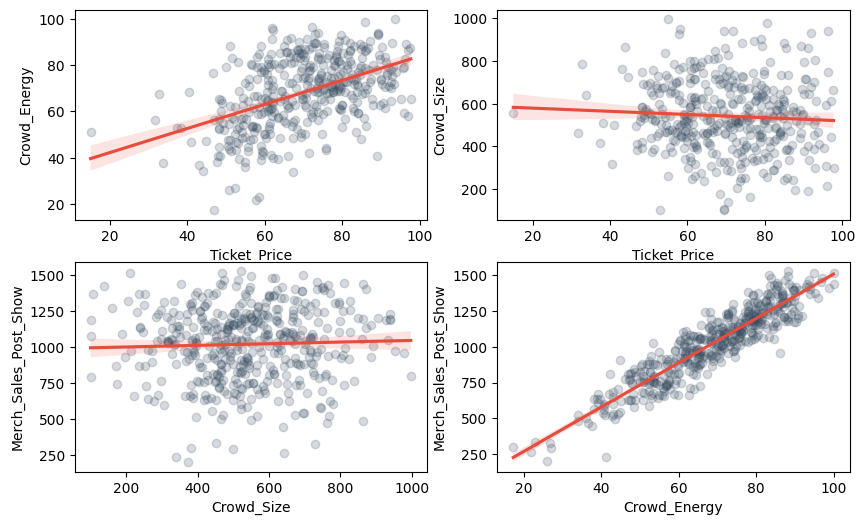

In [452]:
fig,ax= plt.subplots(2,2, figsize=(10,6))
sns.regplot(data=gamma, x='Ticket_Price', y='Crowd_Energy', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[0][0])
sns.regplot(data=gamma, x='Ticket_Price', y='Crowd_Size', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[0][1])
sns.regplot(data=gamma, x='Crowd_Energy', y='Merch_Sales_Post_Show', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[1][1])
sns.regplot(data=gamma, x='Crowd_Size', y='Merch_Sales_Post_Show', scatter_kws={'alpha':0.2, 'color':'#34495e'}, line_kws={'color':'#e74c3c'}, ax=ax[1][0])

In [558]:
gamma['Ticket_Price'].fillna(gamma['Ticket_Price'].median(),inplace=True)
gamma['Crowd_Energy'].fillna(gamma['Crowd_Energy'].median(),inplace=True)

In [559]:
ticket_price = np.linspace(10, 1000, 1000)

In [560]:
from sklearn.linear_model import LinearRegression

In [561]:
lr1 = LinearRegression()
lr1.fit(gamma[['Ticket_Price']], gamma['Crowd_Size'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [562]:
lr10=lr1.intercept_

In [563]:
lr11=lr1.coef_[0]

In [580]:
cr_size= lr11*ticket_price +lr10
cr_size = np.clip(cr_size, 0, 800)

In [565]:
lr2 = LinearRegression()
lr2.fit(gamma[['Ticket_Price', 'Crowd_Size']], gamma['Crowd_Energy'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [566]:
lr20=lr2.intercept_

In [567]:
lr21=lr2.coef_

In [581]:
cr_energy=lr20 + lr21[0]*ticket_price + lr21[1]*cr_size
cr_energy = np.clip(cr_energy, 0, 100)

In [570]:
lr3 = LinearRegression()
lr3.fit(gamma[['Crowd_Energy', 'Crowd_Size']], gamma['Merch_Sales_Post_Show'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [571]:
lr30=lr3.intercept_

In [572]:
lr31=lr2.coef_

In [582]:
merch_sales=lr30 + lr31[0]*cr_energy +lr31[1]*cr_size
merch_sales = np.maximum(merch_sales, 0)

In [583]:
profit= (cr_size*(ticket_price-8)) + merch_sales - 5000

In [584]:
np.argmax(profit)

np.int64(391)

In [585]:
np.argmax(cr_energy)

np.int64(122)

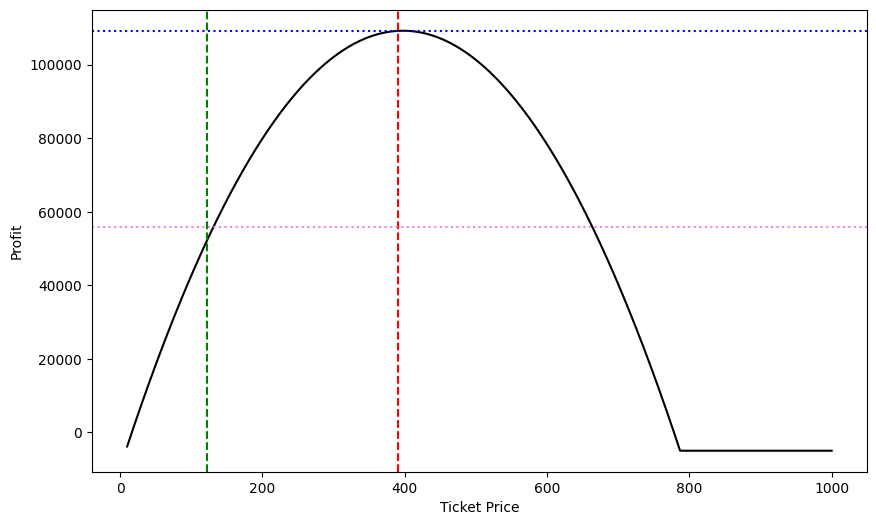

In [586]:
plt.figure(figsize=(10, 6))
plt.plot(ticket_price, profit, color='black', label='Profit')
plt.xlabel("Ticket Price")
plt.ylabel("Profit")
plt.axvline(x=np.argmax(profit), color='red', linestyle='--', label='Vertical Line')
plt.axhline(y=profit[np.argmax(profit)], color='blue', linestyle=':', label='Horizontal Line')
plt.axvline(x=np.argmax(cr_energy), color='green', linestyle='--', label='Vertical Line')
plt.axhline(y=profit[122], color='violet', linestyle=':', label='Horizontal Line')

In [578]:
profit[np.argmax(profit)]

np.float64(109219.31139212675)

In [579]:
profit[np.argmax(cr_energy)]

np.float64(55719.12642183492)

# All my thinkings and decisions are heavily due to this youtube channel [CampusX](https://www.youtube.com/@campusx-official)

Didn't have enogh time to explore other channels